# Кросс-активная long–short momentum-стратегия

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
%matplotlib inline

import datetime
from tqdm.notebook import tqdm

In [2]:
import os, re
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['font.family'] = 'Times New Roman'

In [4]:
# US business month start dates + US Federal Holidays
# Creates a CustomBusinessMonthBegin offset that accounts for the first business day of the month and skips US federal holidays.
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessMonthBegin
from pandas.tseries.offsets import CustomBusinessDay

us_bms = CustomBusinessMonthBegin(calendar=USFederalHolidayCalendar())

pd.date_range("2024-01-01", "2024-12-31", freq=us_bms)

DatetimeIndex(['2024-01-02', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-03', '2024-07-01', '2024-08-01',
               '2024-09-03', '2024-10-01', '2024-11-01', '2024-12-02'],
              dtype='datetime64[ns]', freq='CBMS')

## Подготовка данных

In [5]:
# Предобработка: парсинг, сортировка, индексация
df = pd.read_csv('futures-pnls.csv')  
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True).dt.tz_convert('UTC').dt.tz_localize(None)    # приведение к UTC и снятие tz
df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)                                      # сортировка по дате и удаление NaT
gdf = df.set_index('Date')                                                                                      # установка индекса по дате
cols = [c for c in df.columns if c != 'Date']                                                                   # список тикеров
df

,Date,BOA,BPA,BTC,CAA,CCA,CLA,CNA,CPA,CTA,...,MXA,NGA,NKD,PAA,PLA,SBA,SFA,USAA,VX,WHA
0,2011-12-01 00:00:00,NaN,10000000.00,NaN,10000000.00,NaN,10000000.00,NaN,10000000.00,NaN,...,10000000.00,10000000.00,NaN,10000000.0,10000000.0,NaN,10000000.00,10000000.0,NaN,NaN
1,2011-12-01 00:01:00,NaN,10000287.12,NaN,9999772.48,NaN,10000154.60,NaN,9997772.44,NaN,...,NaN,NaN,NaN,9999949.0,NaN,NaN,9999881.50,9999303.0,NaN,NaN
2,2011-12-01 00:02:00,NaN,10000749.62,NaN,9999772.48,NaN,9999754.60,NaN,9998009.94,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10000194.00,9998678.0,NaN,NaN
3,2011-12-01 00:03:00,NaN,10000749.62,NaN,9999292.48,NaN,9999754.60,NaN,9998484.94,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10000506.50,9998053.0,NaN,NaN
4,2011-12-01 00:04:00,NaN,10000518.37,NaN,9999292.48,NaN,9999754.60,NaN,NaN,NaN,...,NaN,9999600.32,10000000.00,NaN,NaN,NaN,10000819.00,9997428.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760379,2025-03-31 22:55:00,NaN,9313279.10,NaN,8614509.76,NaN,9885135.44,NaN,10614414.02,NaN,...,10474583.82,8802197.16,NaN,10508833.2,9693226.7,NaN,NaN,10226883.2,7702534.88,NaN
4760380,2025-03-31 22:56:00,NaN,9313004.10,10765070.3,8614174.76,NaN,9885135.44,NaN,10615289.02,NaN,...,10474268.82,8802457.16,11795475.32,NaN,9693341.7,NaN,9440847.88,10226883.2,7702534.88,NaN
4760381,2025-03-31 22:57:00,NaN,9312729.10,10765070.3,8614174.76,NaN,9885135.44,NaN,10615114.02,NaN,...,10475213.82,8802327.16,NaN,NaN,9693111.7,NaN,9440847.88,10226883.2,7703284.88,NaN
4760382,2025-03-31 22:58:00,NaN,9313004.10,NaN,8613839.76,NaN,9885275.44,NaN,10615464.02,NaN,...,10475528.82,8802587.16,NaN,NaN,NaN,NaN,9440547.88,10226883.2,NaN,NaN


Построим отчёт по качеству данных для каждого тикера, оценив пропуски относительно только торговых дней США (US business days), начиная с первой даты доступных котировок.

In [6]:
# Построение базового торгового календаря США (US business day календарь)
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
start_day = gdf.index.min().normalize()
end_day   = gdf.index.max().normalize()
base_days = pd.date_range(start_day, end_day, freq=us_bd)

# Дневные «флаги наличия» наблюдений по каждому тикеру в календарных днях
daily_has_all = gdf[cols].resample('D').apply(lambda x: x.notna().any()) # true, если в этот календарный день есть хотя бы одно наблюдение

# Цикл по тикерам: анализ пропусков и лакун
records_us = []
for col in tqdm(cols, desc="US-BD пропуски по дням (исключая неторговые дни)"):
    daily_has = daily_has_all[col]

    # первая реальная дата котировки в календарных днях
    if daily_has.any():
        first_real_day = daily_has.index[daily_has.values].min()
        # первый US-BD день НЕ РАНЬШЕ первой реальной даты
        denom_days = base_days[base_days >= first_real_day]
        if len(denom_days) == 0:
            first_us_bd = pd.NaT
            days_from_first_US = 0
            pct_missing_US = np.nan
            longest_gap_US = np.nan
        else:
            first_us_bd = denom_days[0]
            # булев ряд «данные были в этот календарный день»
            # приводим к US-BD индексу; дни вне календаря не учитываются
            has_on_us = daily_has.reindex(denom_days, fill_value=False)
            days_from_first_US = int(len(denom_days))
            pct_missing_US = float((~has_on_us).mean() * 100.0)

            # длина максимального подряд идущего блока отсутствий НА US-календаре
            a = (~has_on_us).to_numpy()
            if a.size:
                b = np.diff(np.concatenate(([False], a, [False])).astype(int))
                starts = np.where(b == 1)[0]; ends = np.where(b == -1)[0]
                longest_gap_US = int((ends - starts).max()) if len(starts) else 0
            else:
                longest_gap_US = np.nan
    else:
        first_us_bd = pd.NaT
        days_from_first_US = 0
        pct_missing_US = np.nan
        longest_gap_US = np.nan

    records_us.append({'ticker': col,'first_us_business_day': first_us_bd,'days_from_first_usbd': days_from_first_US,
                       'pct_missing_from_first_days_US': pct_missing_US,'longest_gap_days_US': longest_gap_US})
    
# Финальный отчёт по тикерам: пропуски в US‑днях (отсортировано по убыванию)
missing_report = (pd.DataFrame.from_records(records_us).sort_values('pct_missing_from_first_days_US', 
                                                                    ascending=False,na_position='last').reset_index(drop=True))

US-BD пропуски по дням (исключая неторговые дни):   0%|          | 0/26 [00:00<?, ?it/s]

In [7]:
missing_report

,ticker,first_us_business_day,days_from_first_usbd,pct_missing_from_first_days_US,longest_gap_days_US
0,GLA,2011-12-01,3340,0.538922,2
1,LHA,2011-12-01,3340,0.479042,2
2,GCA,2011-12-01,3340,0.389222,1
3,SBA,2011-12-01,3340,0.389222,1
4,PLA,2011-12-01,3340,0.389222,1
5,PAA,2011-12-01,3340,0.389222,1
6,NGA,2011-12-01,3340,0.389222,1
7,KCA,2011-12-01,3340,0.389222,1
8,BOA,2011-12-01,3340,0.389222,1
9,CLA,2011-12-01,3340,0.389222,1


In [8]:
# Оценка числа «торговых дней в году» эмпирически по US-календарю
days_in_year = (pd.Series(1, index=base_days).groupby(base_days.year).sum().median())
days_in_year = int(days_in_year)  # Количество торговых дней в году
days_in_year

251

In [9]:
# Фильтрация тикеров по критериям качества данных. Оставляет только те активы, которые:
min_years = 3.0                             # имеют минимум 3 года истории (в US-днях),
max_missing_from_first_days = 25.0          # имеют <= 25% пропусков в своей истории,
max_gap_days = 5                            # не имеют пропусков длиннее 5 подряд торговых дней.

cond_len   = missing_report['days_from_first_usbd'] >= int(days_in_year * min_years)
cond_pmiss = missing_report['pct_missing_from_first_days_US'] <= max_missing_from_first_days
cond_gap   = missing_report['longest_gap_days_US'] <= max_gap_days

tickers_kept = (missing_report.loc[cond_len & cond_pmiss & cond_gap, 'ticker'].dropna().tolist())
print("Оставляем тикеров:", len(tickers_kept))

Оставляем тикеров: 26


In [10]:
# Расчёт дневных инкрементов
cols = ['Date'] + tickers_kept
ret = df[cols].copy()
ret[tickers_kept] = ret[tickers_kept].diff()

# Агрегация сразу по US business day
ret_daily_cents = (ret.set_index('Date')[tickers_kept].resample(us_bd).sum(min_count=1)) 

# Удаление дней, где все значения NaN (ни у одного тикера нет сделки).
ret_daily_cents = ret_daily_cents.loc[~ret_daily_cents.isna().all(axis=1)]

# Перевод в «реальные» доходности
ret_daily_dollars = ret_daily_cents / 100.0          # Перевод из центов в доллары
capital_base = 100_000.0
ret_daily_frac = ret_daily_dollars / capital_base    # Делиv на капитал b получает доходность как долю от капитала

In [11]:
ret_daily_frac

,GLA,LHA,GCA,SBA,PLA,PAA,NGA,KCA,BOA,CLA,...,USAA,BTC,BPA,MXA,EP,NKD,EUA,CAA,SFA,DAA
Date,,,,,,,,,,,,,,,,,,,,,
2011-12-01,-0.000746,-0.002286,-0.000306,-0.001141,0.001403,0.002725,0.001072,0.000601,0.000141,-0.000765,...,-0.001195,NaN,-0.000041,-0.000840,-0.000013,0.000455,0.000559,0.001561,0.000426,-0.000580
2011-12-02,-0.000816,-0.002350,-0.000180,-0.000195,-0.000652,0.001600,-0.000480,-0.003291,0.001382,0.001280,...,0.002063,NaN,-0.001827,-0.000788,0.000000,0.001300,-0.001800,-0.002304,-0.001187,-0.000270
2011-12-05,-0.004743,-0.002444,-0.002868,0.002404,-0.000923,-0.000315,-0.001536,0.001804,-0.001805,-0.000420,...,0.000250,NaN,0.001295,0.000788,0.000562,0.000520,-0.000360,0.000720,0.000406,0.000486
2011-12-06,-0.000969,0.002632,0.000744,0.000974,0.000367,0.003850,0.000528,0.000171,0.000931,0.000470,...,-0.003063,NaN,-0.000601,0.000472,0.000112,0.000455,-0.000030,0.003168,-0.001313,-0.000675
2011-12-07,0.000816,-0.000987,0.001536,-0.005587,0.000668,-0.000230,-0.001104,-0.002462,0.001269,-0.000530,...,0.001063,NaN,0.002451,-0.000525,0.001613,0.000390,0.000210,0.000144,0.000469,0.001539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,0.000462,-0.001020,0.000588,0.002436,0.000720,0.000245,-0.000742,0.000525,0.001208,0.000014,...,0.000075,0.0,0.000748,-0.000693,0.000570,0.000285,-0.000291,0.001428,0.000469,0.000652
2025-03-26,0.000924,0.000867,0.000133,-0.002436,-0.000756,0.000840,-0.000560,-0.002550,0.001145,0.001106,...,-0.000075,0.0,-0.001294,-0.000504,-0.002318,-0.000675,-0.001453,0.000136,-0.000438,-0.000405
2025-03-27,0.004653,0.000612,0.003003,-0.001260,0.003024,0.000630,0.000826,-0.003225,0.005374,-0.000168,...,-0.000225,0.0,0.001351,-0.001228,-0.000405,-0.000540,0.001666,-0.001870,0.000844,0.000202


In [12]:
# Диагностика пропусков в итоговой таблице дневных доходностей
missing_counts = ret_daily_frac.isnull().sum().sort_values(ascending=False)
missing_counts

BTC     1510
GLA        9
LHA        7
CLA        4
CTA        4
CNA        4
CCA        4
CPA        4
WHA        4
BOA        4
PLA        4
KCA        4
SBA        4
GCA        4
PAA        4
NGA        4
VX         3
USAA       1
BPA        0
MXA        0
EP         0
NKD        0
EUA        0
CAA        0
SFA        0
DAA        0
dtype: int64

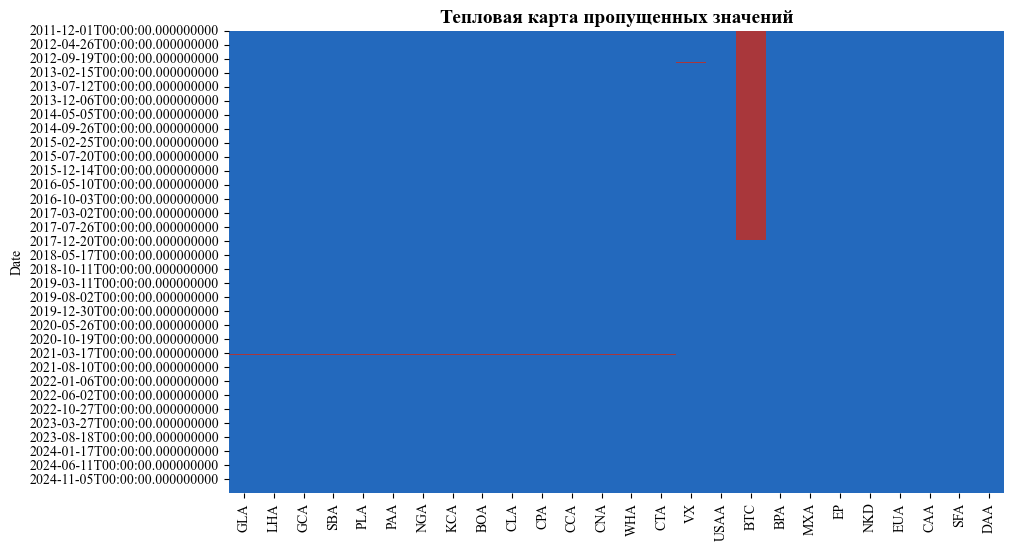

In [13]:
# Создание тепловой карты пропущенных значений
plt.figure(figsize=(10, 6))
sns.heatmap(ret_daily_frac.isnull(), cmap='vlag', cbar=False)
plt.title('Тепловая карта пропущенных значений', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.show()

Заполним короткие внутренние NaN в временном ряду доходностей методом "zero"

In [14]:
def fill_short_gaps_series(s, max_gap, method):
    """
    Заполняет внутренние дырки длиной <= max_gap на ряде доходностей.
    Leading/trailing NaN не трогает.

    method:
      "zero"   : заполнить 0.0 (рекомендовано для доходностей)
      "linear" : линейная интерполяция между соседями
      "ffill"  : протянуть предыдущее значение
    """
    x = s.to_numpy().copy()
    isn = np.isnan(x)
    if not isn.any() or max_gap <= 0:
        return s

    b = np.diff(np.concatenate(([False], isn, [False])).astype(int))
    starts = np.where(b == 1)[0]
    ends   = np.where(b == -1)[0]  # полуинтервалы [start, end)

    for start, end in zip(starts, ends):
        L = end - start
        left, right = start - 1, end
        has_left  = left >= 0 and not np.isnan(x[left])
        has_right = right < len(x) and not np.isnan(x[right])

        if L <= max_gap and has_left and has_right:  # только короткие внутренние дыры
            if method == "zero":
                x[start:end] = 0.0
            elif method == "linear":
                x[start:end] = np.linspace(x[left], x[right], L + 2)[1:-1]
            elif method == "ffill":
                x[start:end] = x[left]
            else:
                raise ValueError("method must be 'zero', 'linear' or 'ffill'")

    return pd.Series(x, index=s.index, name=s.name)

In [15]:
# Применяем латание на доходностях
use_filled = True                 # включить/выключить латание
max_gap = 3                       # максИМАЛЬНАЯ длина "дыры" (в днях)
fill_method = "zero"              # "zero" (по умолчанию) или "linear" / "ffill"

ret_use = ret_daily_frac.copy()
if use_filled:
    for c in tqdm(ret_use.columns, desc="Заполнение пропусков в доходностях"):
        ret_use[c] = fill_short_gaps_series(ret_use[c],max_gap=max_gap,method="zero")

Заполнение пропусков в доходностях:   0%|          | 0/26 [00:00<?, ?it/s]

In [16]:
ret_use

,GLA,LHA,GCA,SBA,PLA,PAA,NGA,KCA,BOA,CLA,...,USAA,BTC,BPA,MXA,EP,NKD,EUA,CAA,SFA,DAA
Date,,,,,,,,,,,,,,,,,,,,,
2011-12-01,-0.000746,-0.002286,-0.000306,-0.001141,0.001403,0.002725,0.001072,0.000601,0.000141,-0.000765,...,-0.001195,NaN,-0.000041,-0.000840,-0.000013,0.000455,0.000559,0.001561,0.000426,-0.000580
2011-12-02,-0.000816,-0.002350,-0.000180,-0.000195,-0.000652,0.001600,-0.000480,-0.003291,0.001382,0.001280,...,0.002063,NaN,-0.001827,-0.000788,0.000000,0.001300,-0.001800,-0.002304,-0.001187,-0.000270
2011-12-05,-0.004743,-0.002444,-0.002868,0.002404,-0.000923,-0.000315,-0.001536,0.001804,-0.001805,-0.000420,...,0.000250,NaN,0.001295,0.000788,0.000562,0.000520,-0.000360,0.000720,0.000406,0.000486
2011-12-06,-0.000969,0.002632,0.000744,0.000974,0.000367,0.003850,0.000528,0.000171,0.000931,0.000470,...,-0.003063,NaN,-0.000601,0.000472,0.000112,0.000455,-0.000030,0.003168,-0.001313,-0.000675
2011-12-07,0.000816,-0.000987,0.001536,-0.005587,0.000668,-0.000230,-0.001104,-0.002462,0.001269,-0.000530,...,0.001063,NaN,0.002451,-0.000525,0.001613,0.000390,0.000210,0.000144,0.000469,0.001539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,0.000462,-0.001020,0.000588,0.002436,0.000720,0.000245,-0.000742,0.000525,0.001208,0.000014,...,0.000075,0.0,0.000748,-0.000693,0.000570,0.000285,-0.000291,0.001428,0.000469,0.000652
2025-03-26,0.000924,0.000867,0.000133,-0.002436,-0.000756,0.000840,-0.000560,-0.002550,0.001145,0.001106,...,-0.000075,0.0,-0.001294,-0.000504,-0.002318,-0.000675,-0.001453,0.000136,-0.000438,-0.000405
2025-03-27,0.004653,0.000612,0.003003,-0.001260,0.003024,0.000630,0.000826,-0.003225,0.005374,-0.000168,...,-0.000225,0.0,0.001351,-0.001228,-0.000405,-0.000540,0.001666,-0.001870,0.000844,0.000202


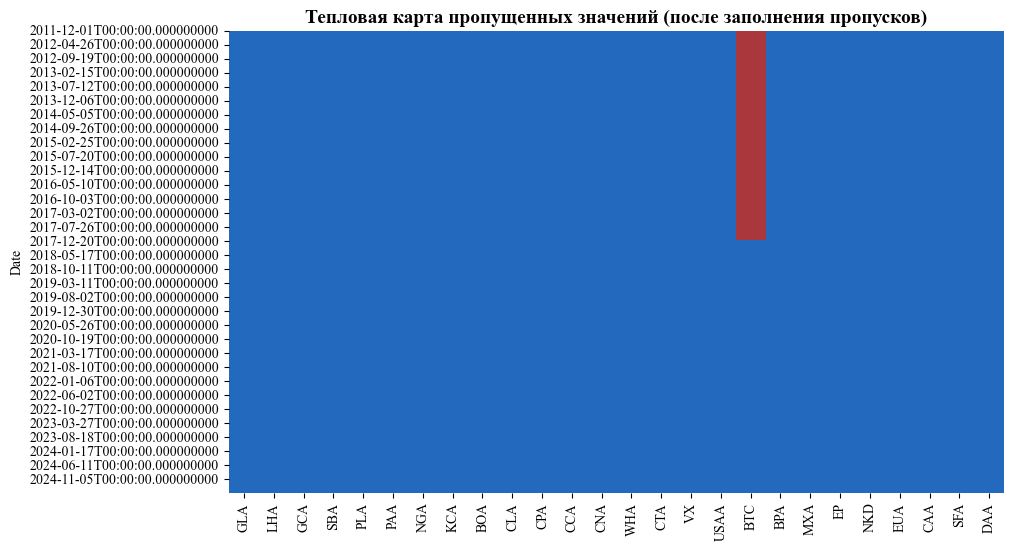

In [88]:
# Создание тепловой карты пропущенных значений
plt.figure(figsize=(10, 6))
sns.heatmap(ret_use.isnull(), cmap='vlag', cbar=False)
plt.title('Тепловая карта пропущенных значений (после заполнения пропусков)', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.savefig(r"Рисунки/тепловая карта пропущенных значений (после заполнения пропусков).png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
ret_use.shape

(3331, 26)

In [96]:
ret_use.describe().apply(lambda s: s.apply('{0:.3f}'.format))#.to_csv('ret_use.xlsx')

,GLA,LHA,GCA,SBA,PLA,PAA,NGA,KCA,BOA,CLA,...,USAA,BTC,BPA,MXA,EP,NKD,EUA,CAA,SFA,DAA
count,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,...,3331.000,1824.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000,3331.000
mean,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,...,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000
std,0.002,0.003,0.002,0.002,0.002,0.001,0.002,0.002,0.002,0.002,...,0.002,0.001,0.002,0.001,0.002,0.001,0.002,0.002,0.002,0.002
min,-0.018,-0.018,-0.015,-0.010,-0.013,-0.006,-0.014,-0.012,-0.010,-0.040,...,-0.013,-0.010,-0.032,-0.010,-0.014,-0.011,-0.011,-0.011,-0.013,-0.011
25%,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,...,-0.001,-0.000,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001,-0.001
50%,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000
75%,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001
max,0.012,0.020,0.013,0.011,0.009,0.007,0.011,0.015,0.009,0.017,...,0.009,0.007,0.015,0.006,0.015,0.009,0.014,0.010,0.015,0.012


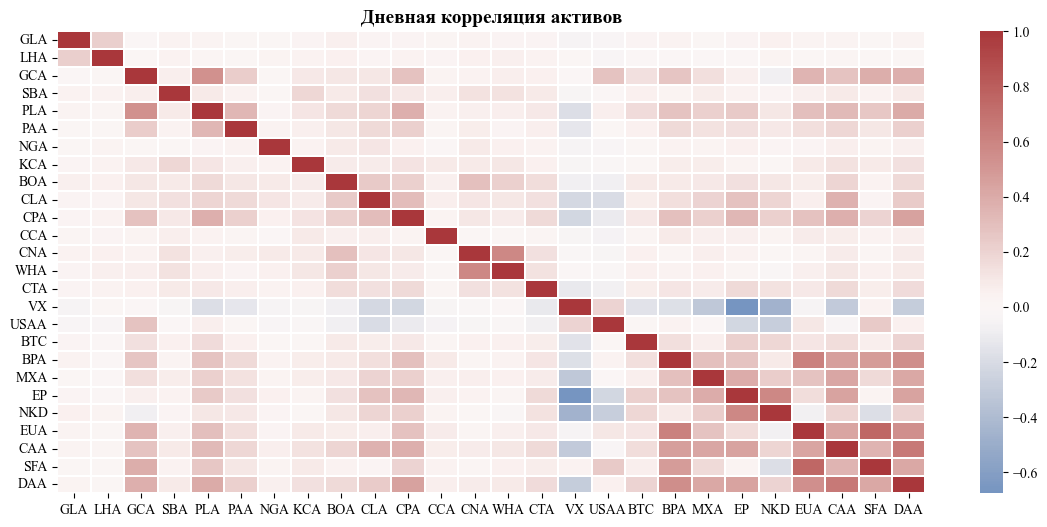

In [22]:
corr = ret_use.corr(min_periods=60)
plt.figure(figsize=(14,6))
sns.heatmap(corr, cmap='vlag', center=0, linewidths=.1)
plt.title("Дневная корреляция активов", fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.savefig(r"Рисунки/дневная корреляция активов.png", dpi=300, bbox_inches="tight")
plt.show()

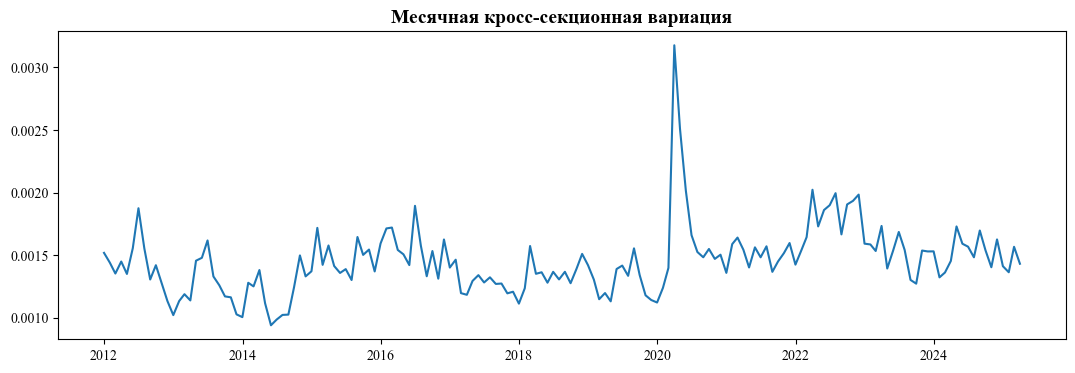

In [32]:
cs_disp = ret_use.abs().mean(axis=1)
cs_disp_m = cs_disp.resample('M').mean()
plt.figure(figsize=(13,4))
plt.plot(cs_disp_m, lw=1.5)
plt.title("Месячная кросс-секционная вариация", fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.savefig(r"Рисунки/месячная кросс-секционная вариация.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
#Сводка по каждому тикеру (µ, σ, Sharpe, покрытие, старт)
per_asset = []
for c in ret_use.columns:
    s = ret_use[c].dropna()
    if s.empty:
        per_asset.append({'ticker': c, 'start': pd.NaT, 'count': 0,'coverage_%': 0.0, 'mu_ann': np.nan,'vol_ann': np.nan, 'sharpe': np.nan})
        continue
    mu_ann  = s.mean() * days_in_year
    vol_ann = s.std(ddof=1) * np.sqrt(days_in_year)
    sharpe  = mu_ann / (vol_ann + 1e-12)
    coverage = ret_use[c].notna().mean() * 100.0
    per_asset.append({'ticker': c,'start': s.index.min(),'count': len(s),'coverage_%': coverage,
        'mu_ann': mu_ann,'vol_ann': vol_ann,'sharpe': sharpe})

assets_report = (pd.DataFrame(per_asset).sort_values('sharpe', ascending=False).reset_index(drop=True))
assets_report

,ticker,start,count,coverage_%,mu_ann,vol_ann,sharpe
0,EP,2011-12-01,3331,100.000000,0.025823,0.029410,0.878042
1,BTC,2017-12-08,1824,54.758331,0.010121,0.018881,0.536034
2,CCA,2011-12-01,3331,100.000000,0.023071,0.043794,0.526817
3,GCA,2011-12-01,3331,100.000000,0.006763,0.030831,0.219345
4,GLA,2011-12-01,3331,100.000000,0.005981,0.035403,0.168934
5,PAA,2011-12-01,3331,100.000000,0.000917,0.016126,0.056879
6,CPA,2011-12-01,3331,100.000000,0.001457,0.036161,0.040295
7,SFA,2011-12-01,3331,100.000000,0.000095,0.027309,0.003492
8,CNA,2011-12-01,3331,100.000000,-0.000127,0.036560,-0.003487
9,USAA,2011-12-01,3331,100.000000,-0.001167,0.028312,-0.041204


Рассчитаем кумулятивную доходность (накопленную, cumulative return) по каждому активу

In [26]:
# Кумулятивная доходность с первой доступной даты по каждому активу
cum_by_asset = pd.DataFrame(index=ret_use.index, columns=ret_use.columns, dtype=float)

for c in tqdm(ret_use.columns, desc="Кумулятивная доходность по активам"):
    s = ret_use[c]
    i0 = s.first_valid_index()
    if i0 is None:
        continue  # у актива нет данных
    s_sub = s.loc[i0:].fillna(0.0)                             # внутри истории NaN => 0 (нет движения в этот день)
    cum_by_asset.loc[i0:, c] = (1.0 + s_sub).cumprod() - 1.0   # в долях

Кумулятивная доходность по активам:   0%|          | 0/26 [00:00<?, ?it/s]

In [27]:
cum_by_asset

,GLA,LHA,GCA,SBA,PLA,PAA,NGA,KCA,BOA,CLA,...,USAA,BTC,BPA,MXA,EP,NKD,EUA,CAA,SFA,DAA
Date,,,,,,,,,,,,,,,,,,,,,
2011-12-01,-0.000746,-0.002286,-0.000306,-0.001141,0.001402,0.002725,0.001072,0.000601,0.000141,-0.000765,...,-0.001195,NaN,-0.000041,-0.000840,-0.000013,0.000455,0.000559,0.001561,0.000426,-0.000580
2011-12-02,-0.001562,-0.004630,-0.000486,-0.001336,0.000749,0.004329,0.000591,-0.002691,0.001523,0.000514,...,0.000865,NaN,-0.001867,-0.001627,-0.000013,0.001756,-0.001242,-0.000746,-0.000762,-0.000850
2011-12-05,-0.006297,-0.007063,-0.003352,0.001065,-0.000174,0.004013,-0.000945,-0.000893,-0.000284,0.000094,...,0.001116,NaN,-0.000575,-0.000841,0.000550,0.002277,-0.001602,-0.000027,-0.000356,-0.000364
2011-12-06,-0.007260,-0.004450,-0.002611,0.002040,0.000193,0.007878,-0.000418,-0.000722,0.000646,0.000564,...,-0.001950,NaN,-0.001176,-0.000369,0.000662,0.002733,-0.001632,0.003141,-0.001668,-0.001039
2011-12-07,-0.006450,-0.005432,-0.001079,-0.003558,0.000861,0.007647,-0.001521,-0.003182,0.001916,0.000034,...,-0.000890,NaN,0.001273,-0.000893,0.002276,0.003124,-0.001422,0.003285,-0.001200,0.000499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,0.068472,-0.159038,0.079357,-0.158377,-0.089612,0.010486,-0.126142,-0.197999,-0.148237,-0.063978,...,-0.021309,0.074924,-0.031684,-0.099039,0.407930,-0.053634,-0.072700,-0.138209,-0.003530,-0.091320
2025-03-26,0.069459,-0.158309,0.079501,-0.160427,-0.090300,0.011335,-0.126632,-0.200044,-0.147261,-0.062943,...,-0.021383,0.074924,-0.032936,-0.099493,0.404667,-0.054273,-0.074048,-0.138091,-0.003966,-0.091688
2025-03-27,0.074435,-0.157794,0.082743,-0.161485,-0.087549,0.011972,-0.125910,-0.202624,-0.142679,-0.063100,...,-0.021603,0.074924,-0.031630,-0.100599,0.404099,-0.054784,-0.072505,-0.139703,-0.003125,-0.091505


In [94]:
cum_by_asset.describe().apply(lambda s: s.apply('{0:.4f}'.format))#.to_csv('cum_by_asset.xlsx')

,GLA,LHA,GCA,SBA,PLA,PAA,NGA,KCA,BOA,CLA,...,USAA,BTC,BPA,MXA,EP,NKD,EUA,CAA,SFA,DAA
count,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,...,3331.0000,1824.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000,3331.0000
mean,-0.0127,-0.0979,-0.0294,-0.1359,-0.0598,-0.0105,-0.0737,-0.1763,-0.1162,-0.0665,...,0.0087,0.0347,-0.0200,-0.0651,0.2102,-0.0162,-0.0309,-0.0842,-0.0187,-0.0466
std,0.0372,0.0506,0.0376,0.0505,0.0401,0.0118,0.0382,0.0693,0.0464,0.0382,...,0.0193,0.0308,0.0238,0.0350,0.1239,0.0228,0.0297,0.0426,0.0141,0.0239
min,-0.1028,-0.1847,-0.0969,-0.2126,-0.1358,-0.0366,-0.1408,-0.2742,-0.2062,-0.2084,...,-0.0364,-0.0152,-0.0921,-0.1236,-0.0065,-0.0588,-0.1084,-0.1533,-0.0617,-0.1023
25%,-0.0418,-0.1395,-0.0611,-0.1747,-0.0911,-0.0188,-0.1069,-0.2366,-0.1458,-0.0916,...,-0.0060,0.0018,-0.0388,-0.0916,0.1107,-0.0408,-0.0527,-0.1136,-0.0301,-0.0620
50%,-0.0185,-0.1151,-0.0307,-0.1483,-0.0735,-0.0109,-0.0763,-0.1941,-0.1169,-0.0669,...,0.0070,0.0445,-0.0226,-0.0809,0.1972,-0.0093,-0.0266,-0.0979,-0.0178,-0.0480
75%,0.0192,-0.0521,-0.0030,-0.1010,-0.0185,-0.0013,-0.0455,-0.1247,-0.1030,-0.0443,...,0.0215,0.0598,-0.0015,-0.0278,0.3387,0.0030,-0.0097,-0.0723,-0.0070,-0.0334
max,0.0744,0.0107,0.0870,0.0037,0.0230,0.0165,0.0011,0.0006,0.0132,0.0046,...,0.0541,0.0816,0.0341,0.0059,0.4245,0.0273,0.0252,0.0136,0.0107,0.0148


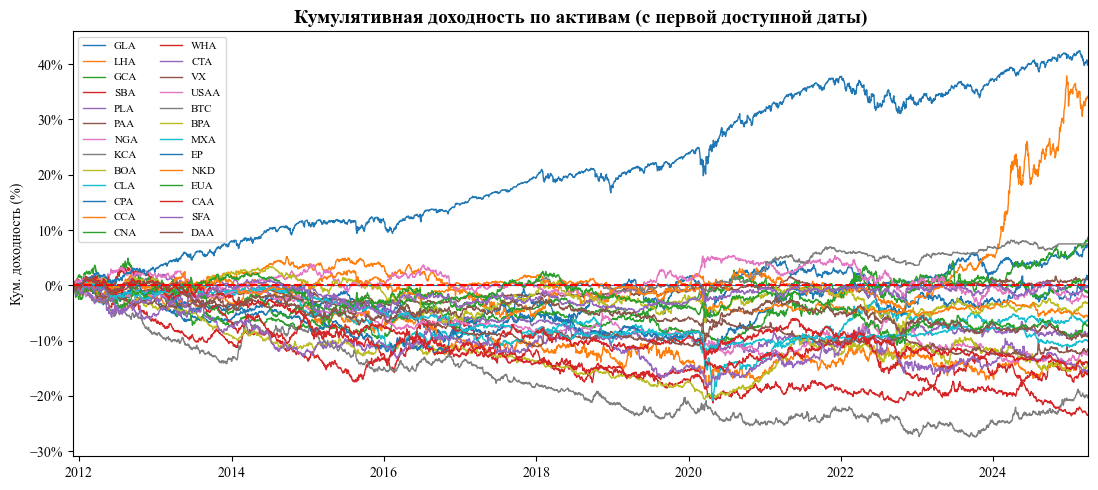

In [34]:
plt.figure(figsize=(11, 5))
for c in cum_by_asset.columns:
    if cum_by_asset[c].notna().any():
        plt.plot(cum_by_asset.index, cum_by_asset[c], label=c, linewidth=1)

plt.axhline(0.0, linewidth=0.8)
plt.title('Кумулятивная доходность по активам (с первой доступной даты)', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.ylabel('Кум. доходность (доли)')
plt.legend(ncol=2, fontsize=8)
plt.ylabel('Кум. доходность (%)')
plt.tight_layout()

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.margins(x=0)
ax.axhline(0, color='red', linestyle='--')
plt.savefig(r"Рисунки/кумулятивная доходность по активам.png", dpi=300, bbox_inches="tight")
plt.show()

Построение индивидуальных графиков:   0%|          | 0/26 [00:00<?, ?it/s]

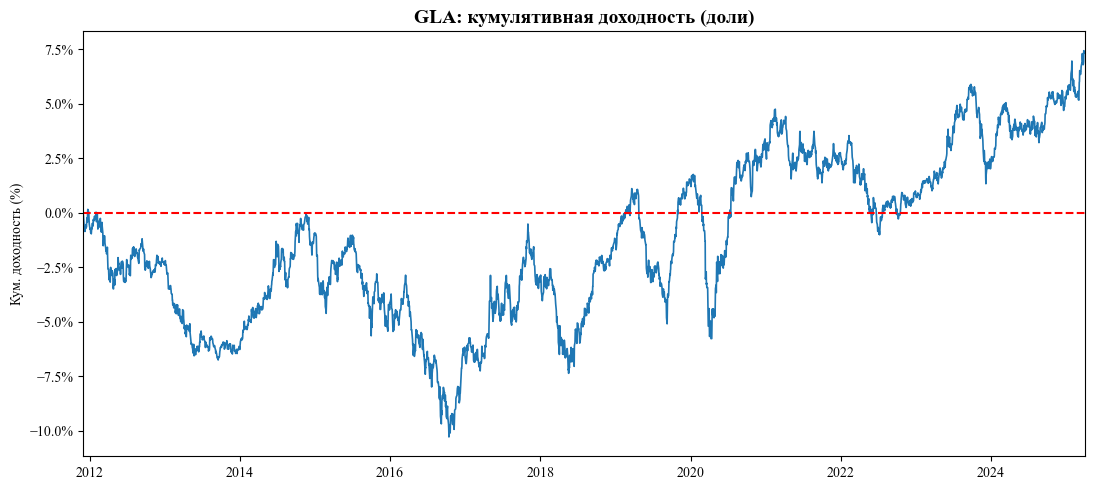

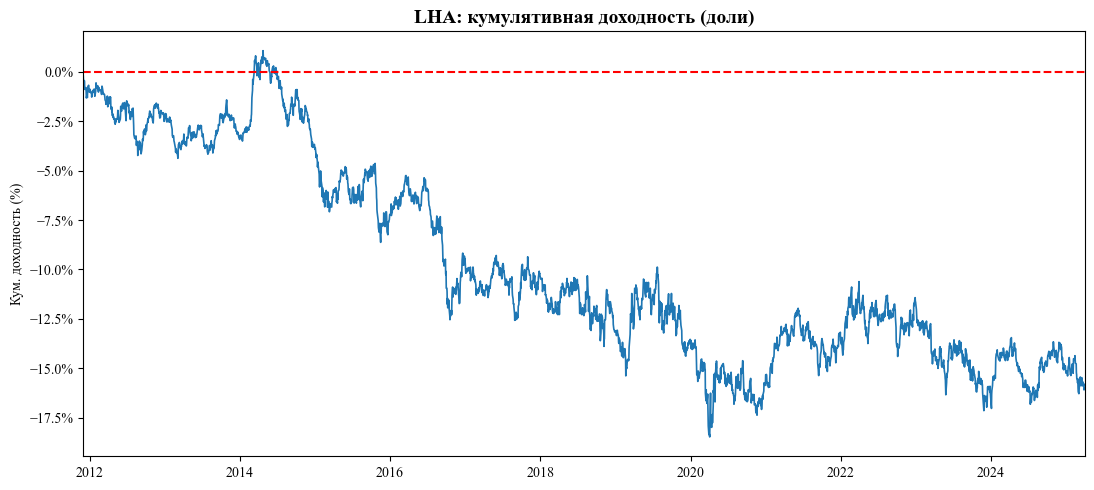

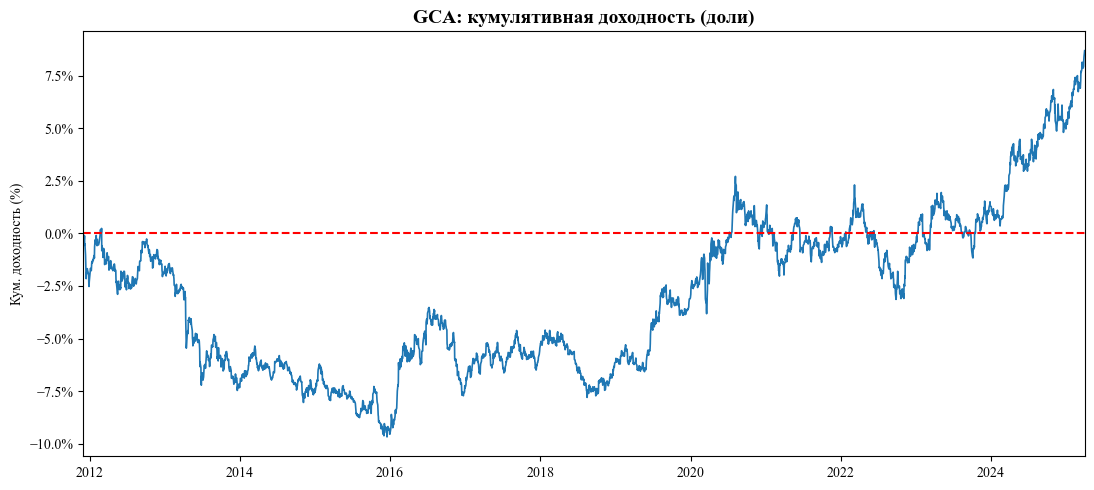

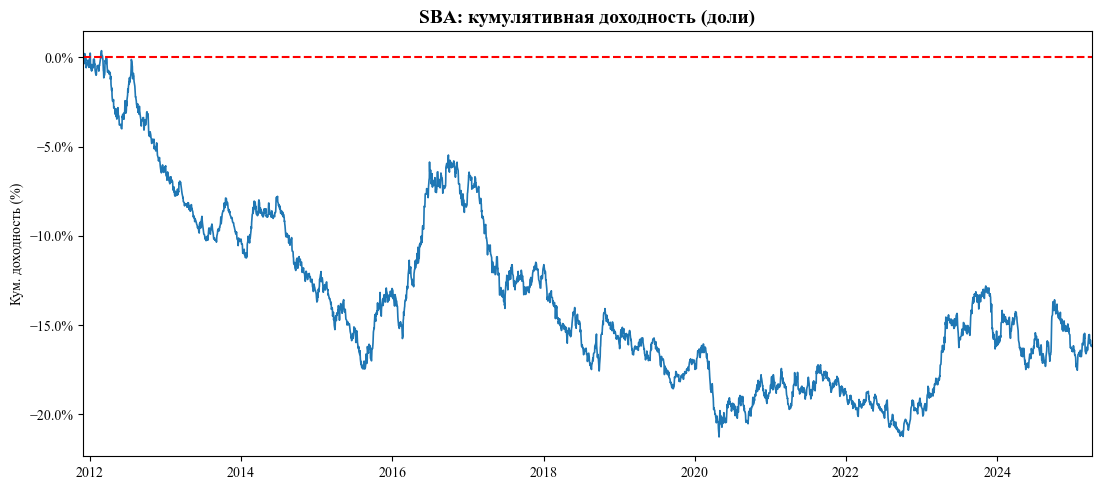

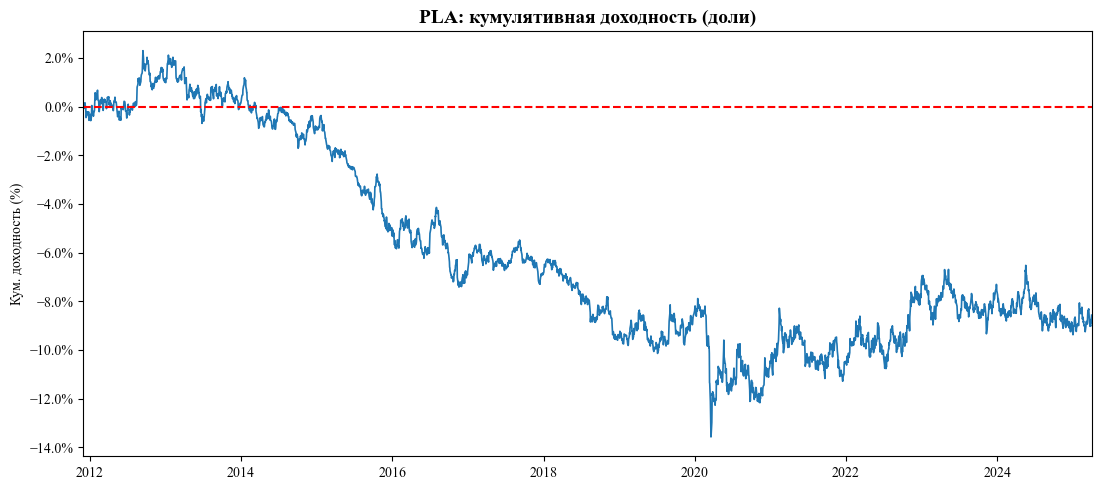

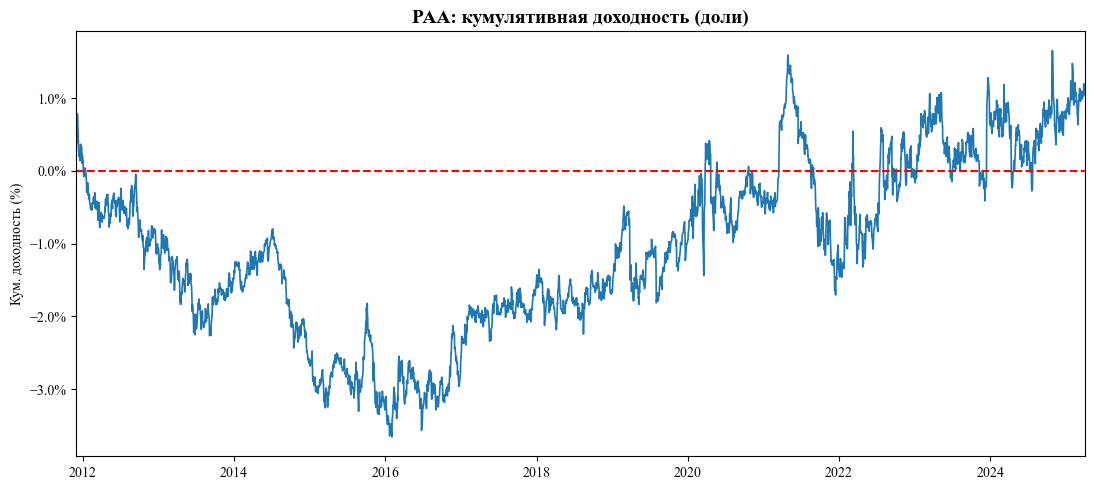

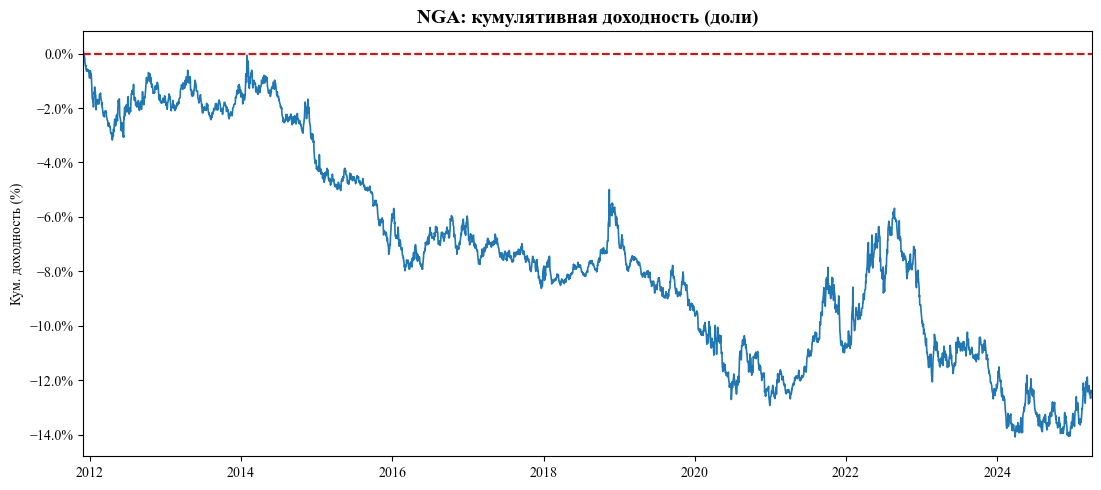

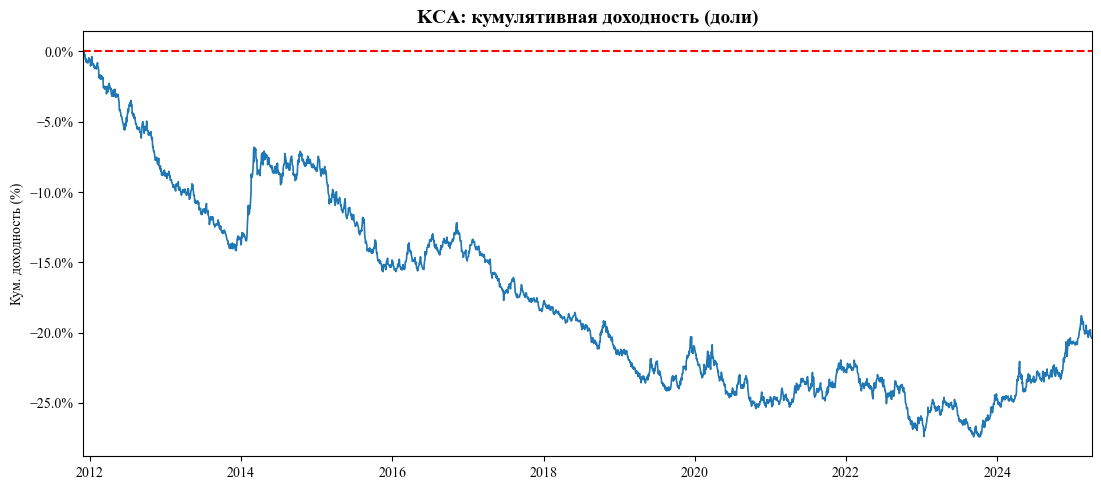

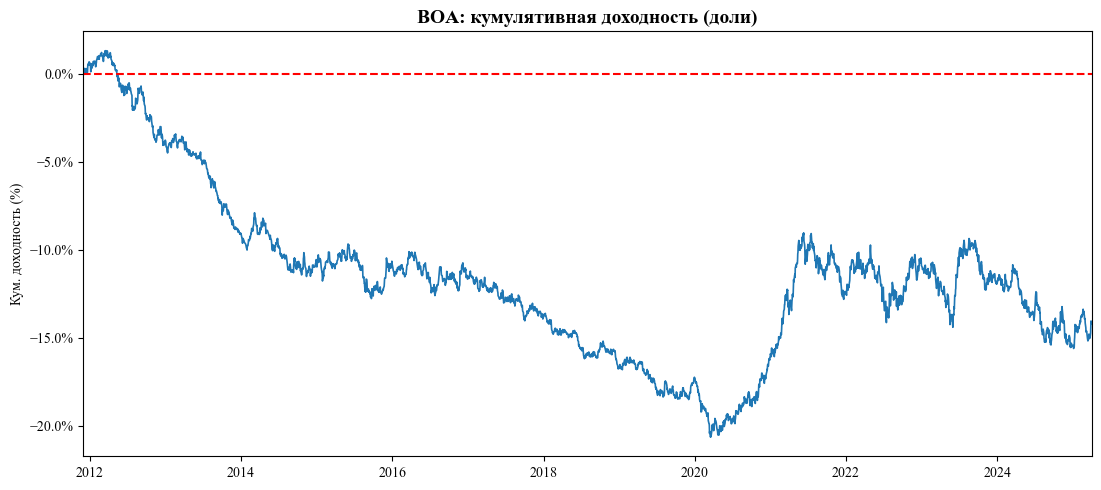

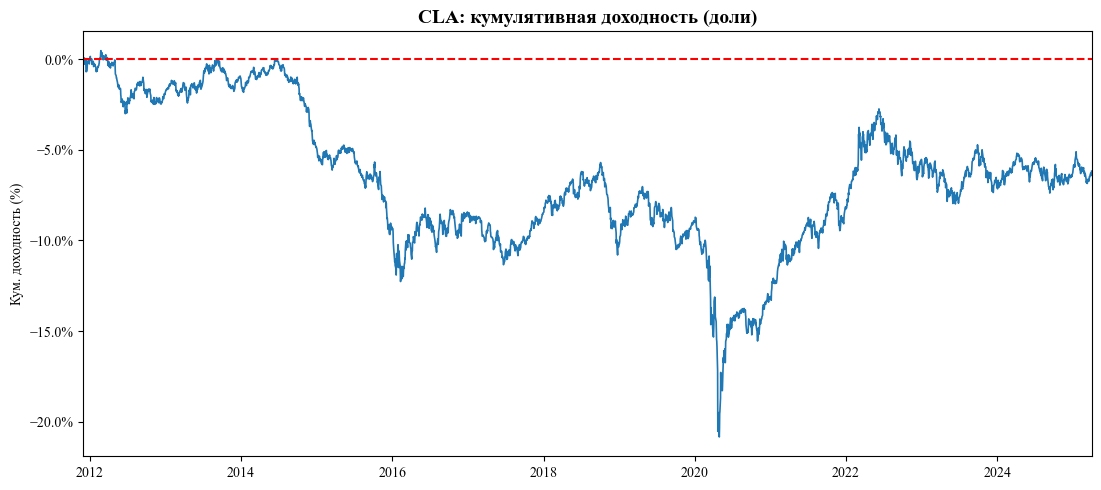

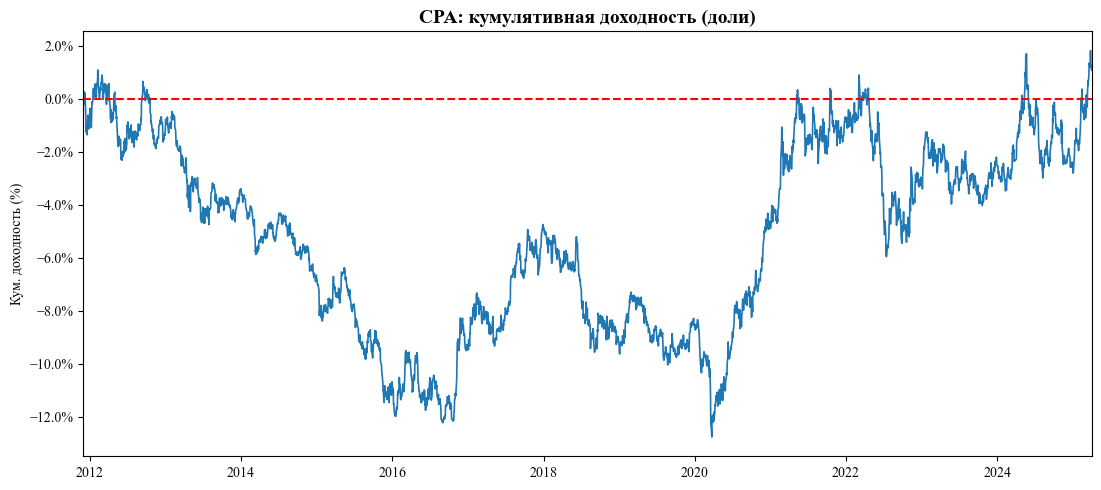

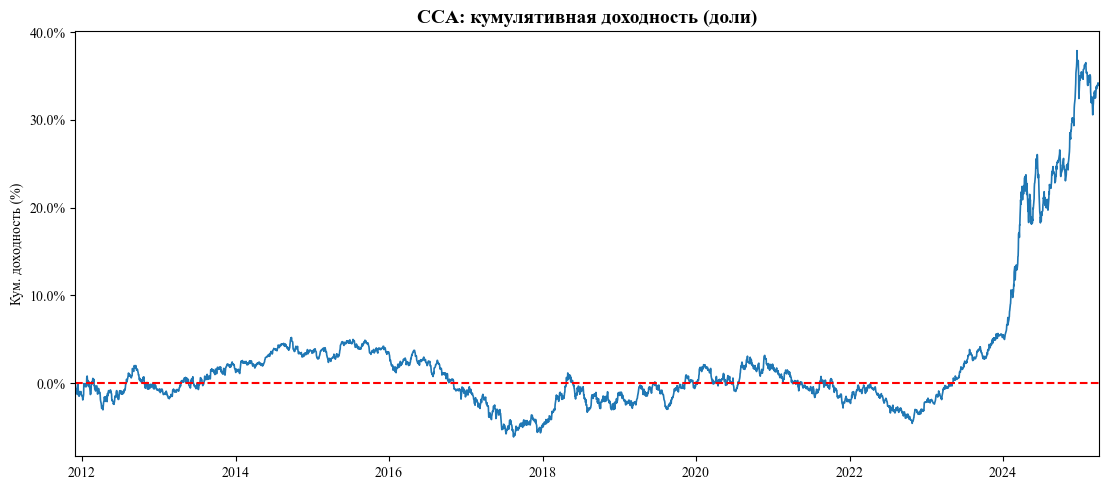

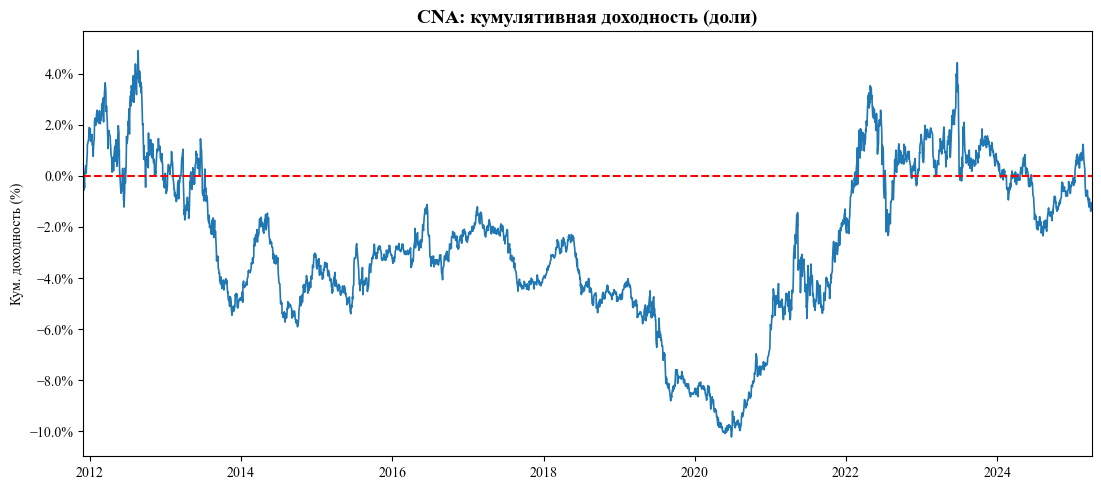

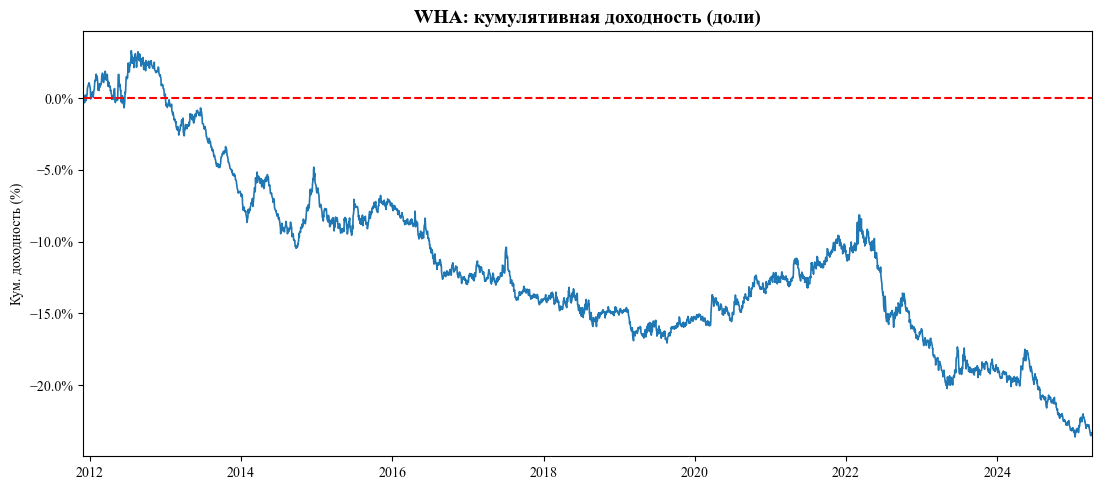

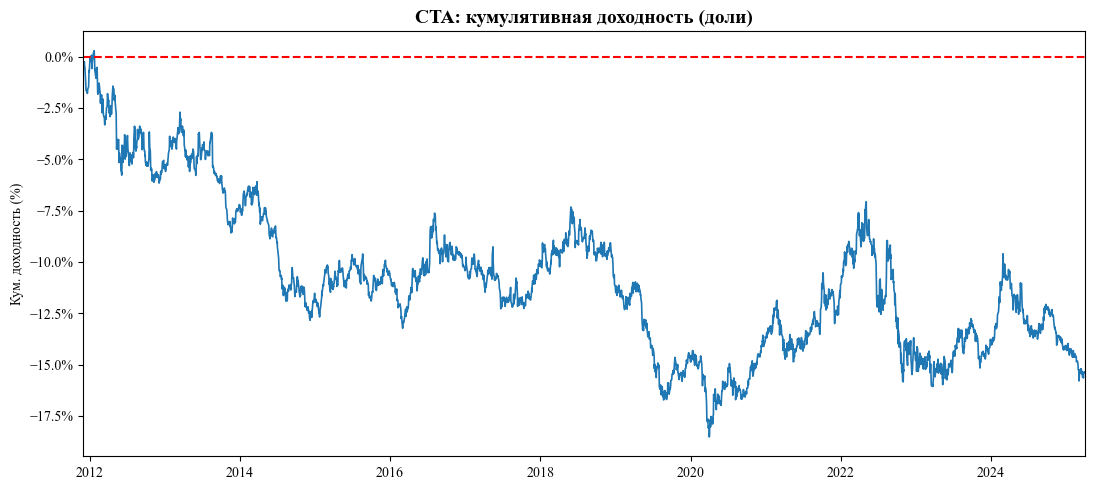

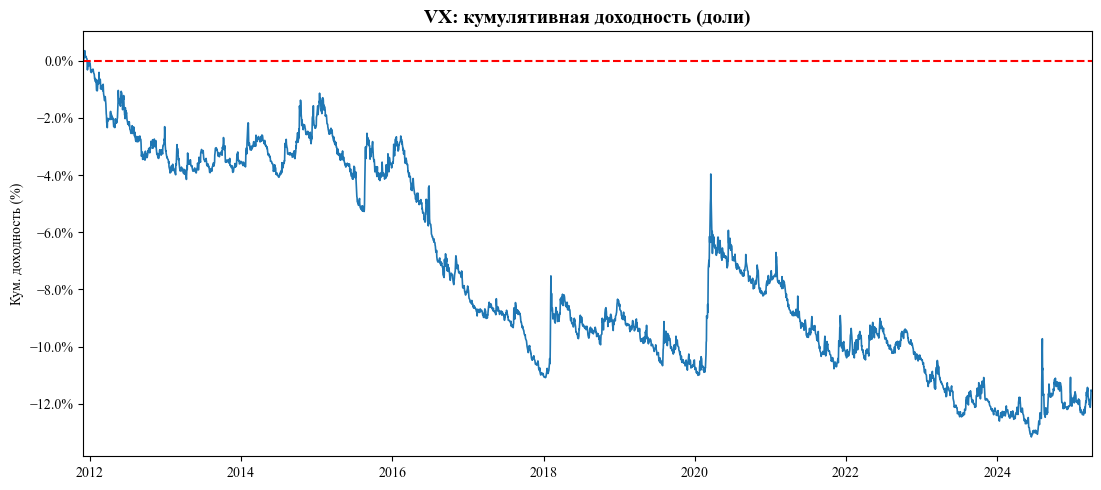

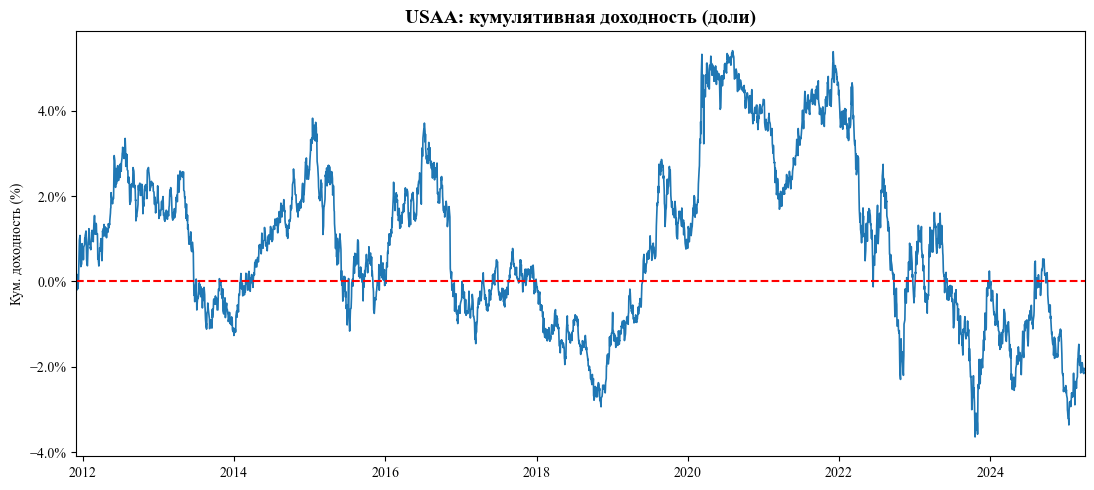

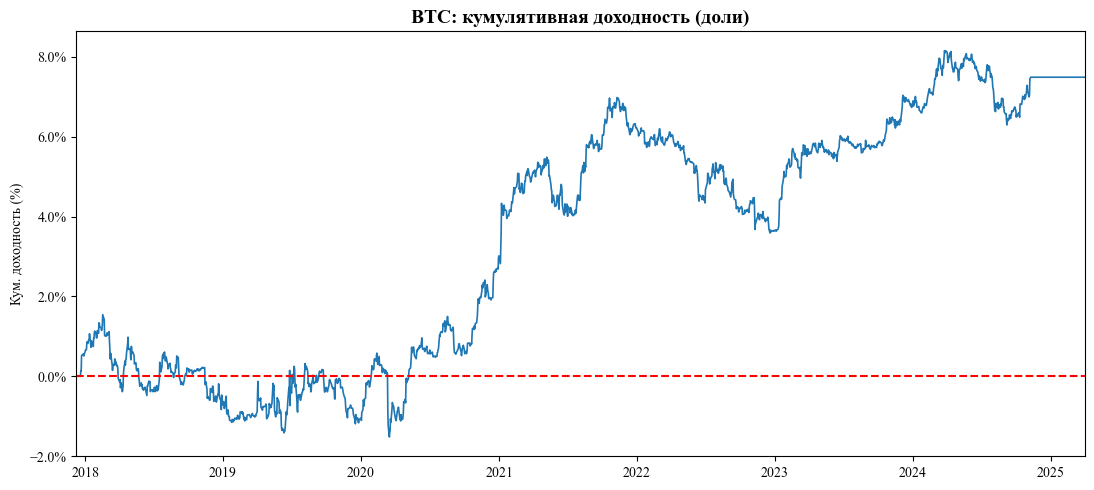

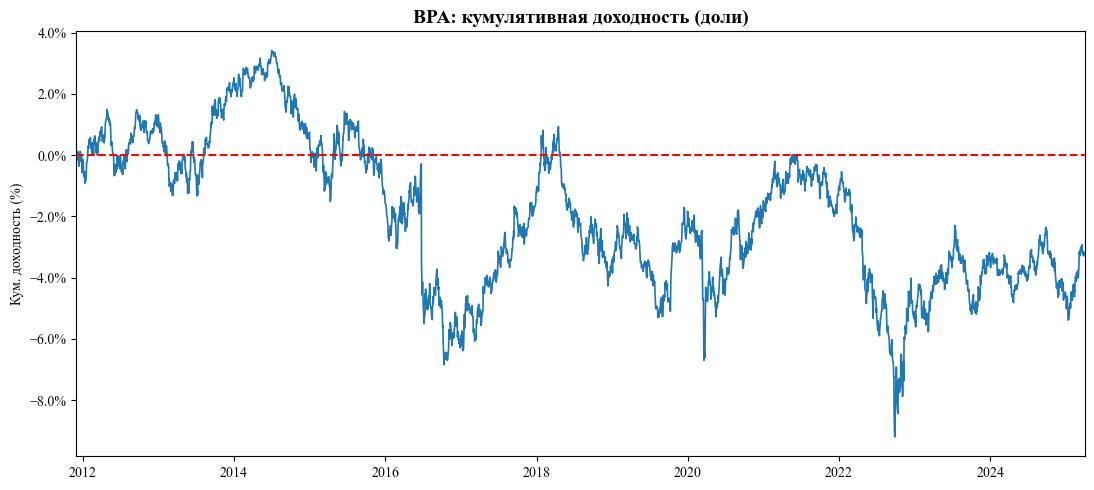

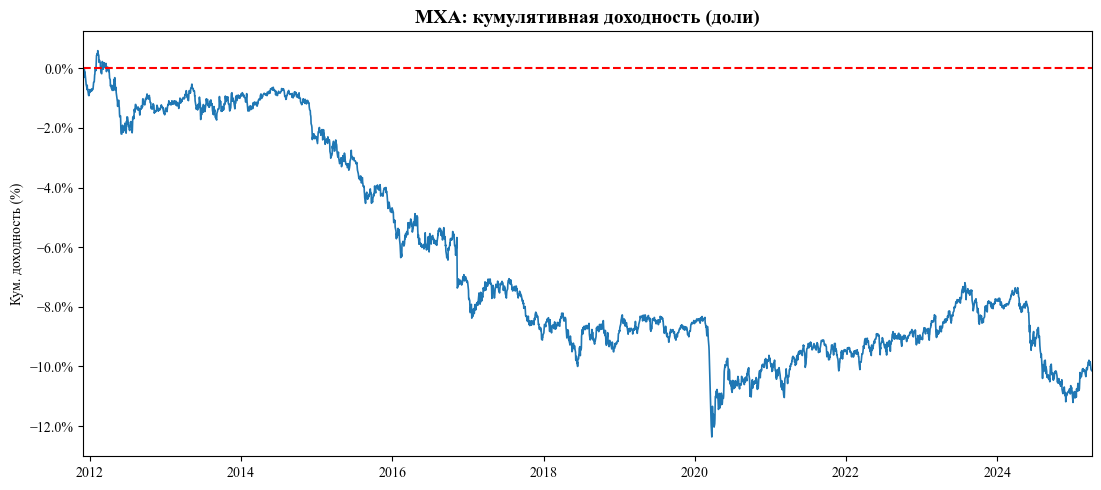

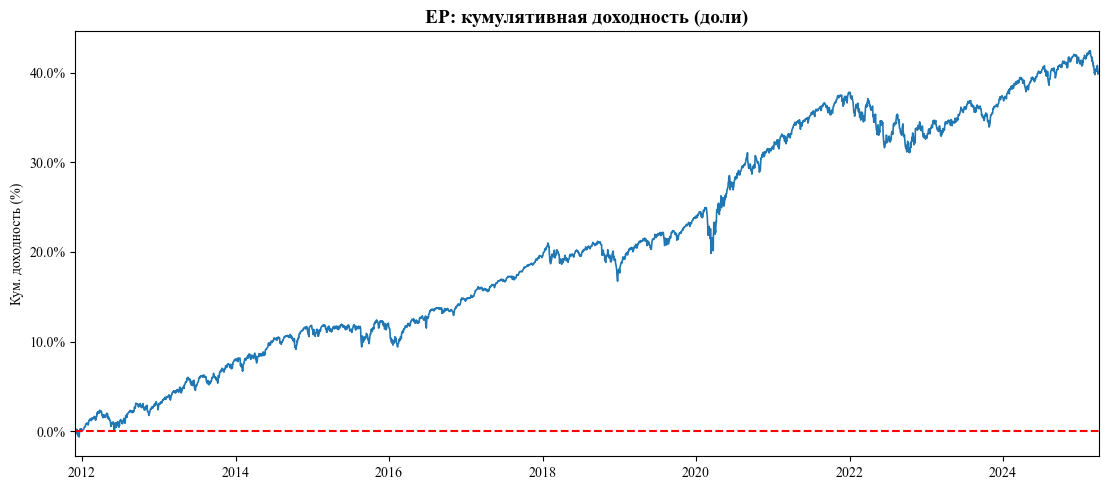

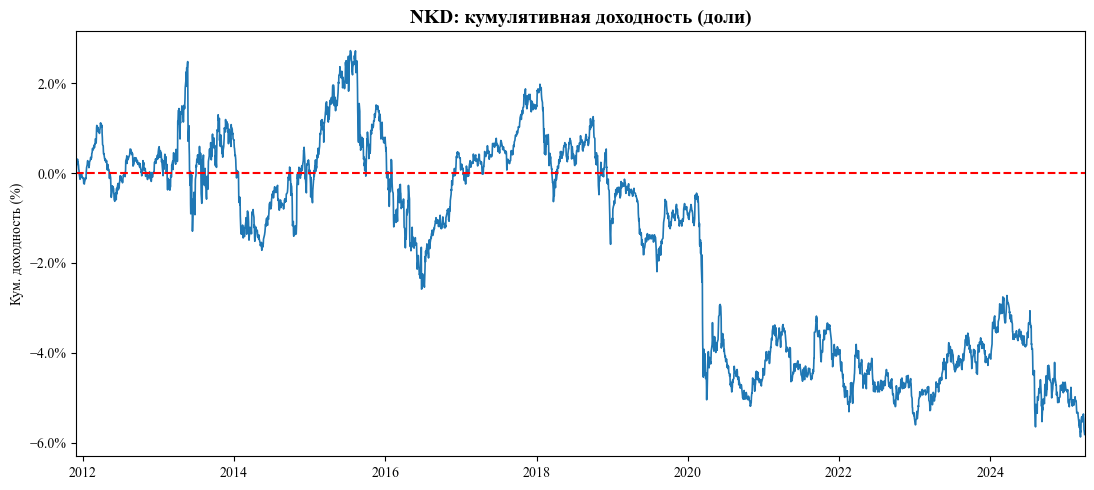

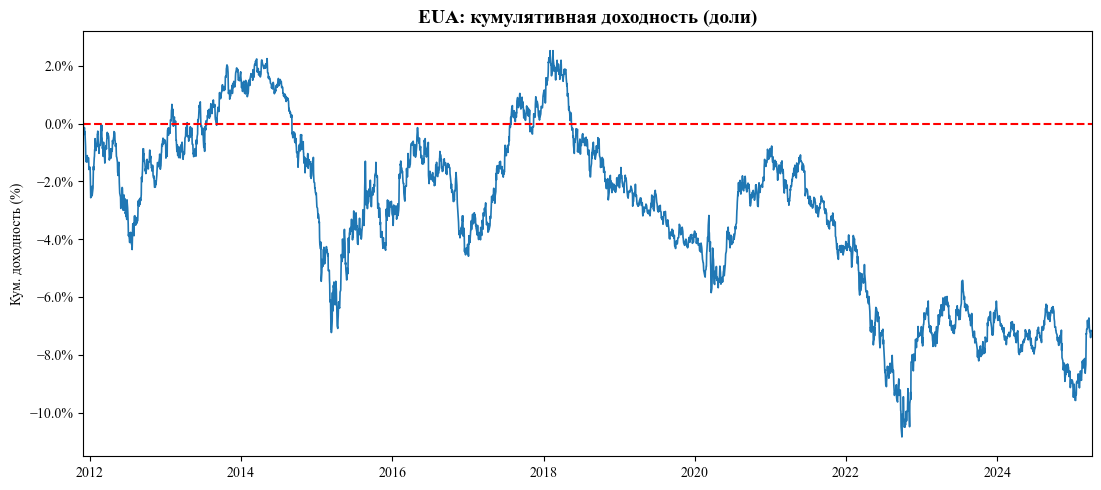

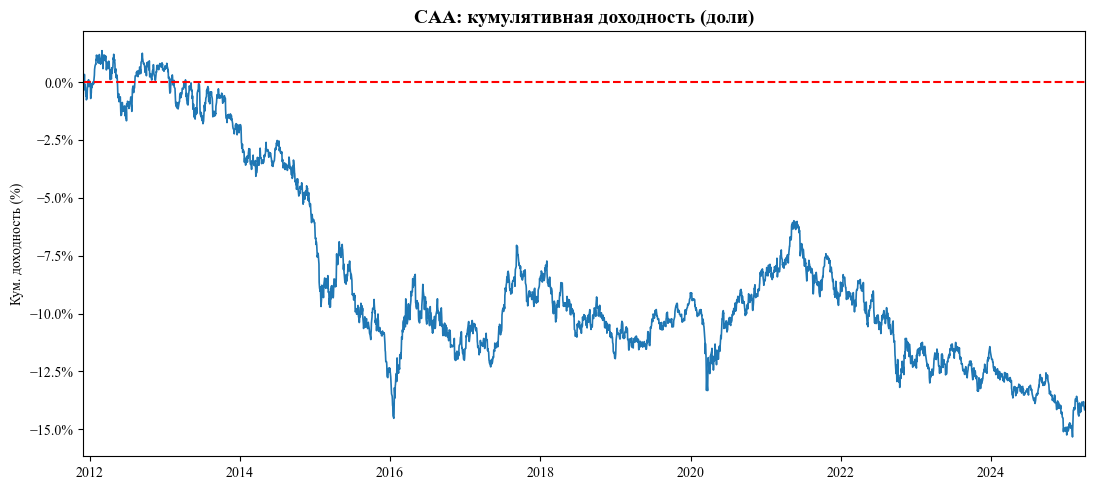

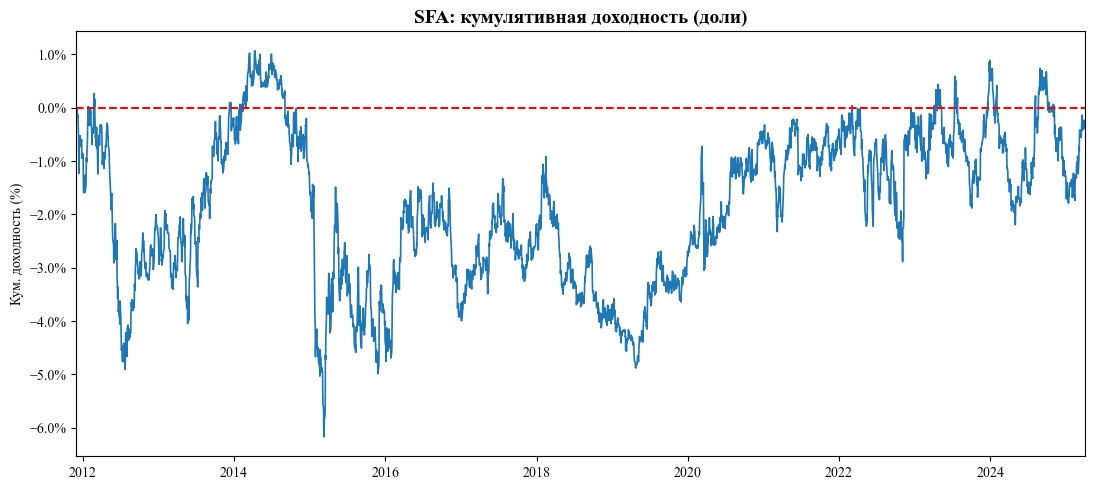

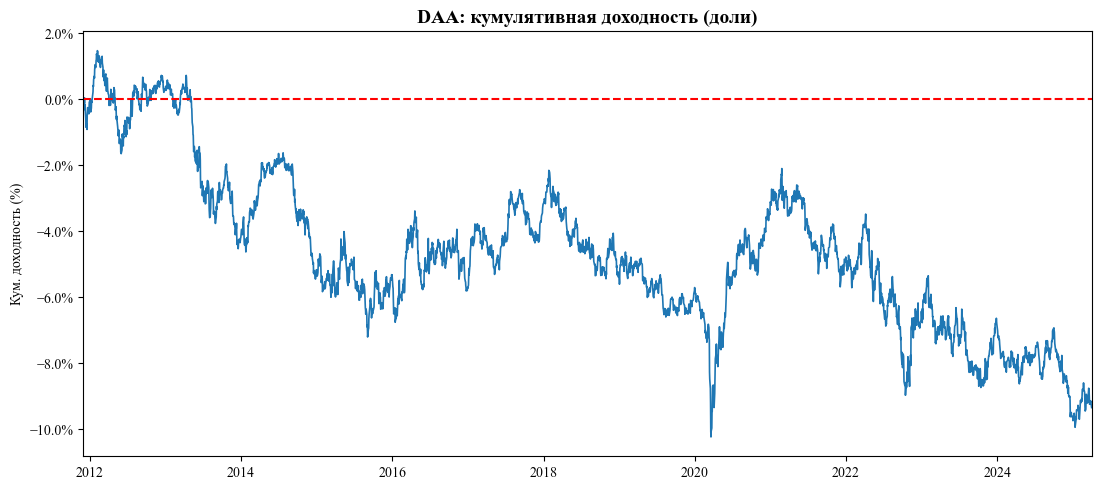

In [35]:
for c in tqdm(cum_by_asset.columns, desc="Построение индивидуальных графиков"):
    if cum_by_asset[c].notna().any():
        plt.figure(figsize=(11, 5))
        plt.plot(cum_by_asset.index, cum_by_asset[c], linewidth=1.2)
        #plt.axhline(0.0, linewidth=0.8)
        plt.title(f'{c}: кумулятивная доходность (доли)', fontdict={'fontweight': 'bold', 'fontsize': 14})
        plt.ylabel('Кум. доходность (%)')
        plt.tight_layout()

        ax = plt.gca()
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.margins(x=0)
        ax.axhline(0, color='red', linestyle='--')
        plt.show()

In [36]:
# ret_use — дневные арифметические доходности активов (в долях к capital_base).
# Держим активы в арифметике, а лог портфеля возьмём уже после агрегирования.
df_returns = ret_use.copy().fillna(0.0)      # активы

# Добавим кэш с нулевой доходностью, чтобы стратегия могла держать остаток/займ кэша.
if 'CASH' not in df_returns.columns:
    df_returns['CASH'] = 0.0

# Риск-юнверс (исключаем CASH)
risk_cols = df_returns.columns.difference(['CASH'])

## Стратегия

In [37]:
# Additional functions
# Annualized metrics (log-returns assumed)
def Return(rets):     return np.mean(rets) * days_in_year                                       # annualized return estimate

def Volatility(rets): return np.std(rets)  * np.sqrt(days_in_year)                              # annualized volatility estimate
 
def SharpeRatio(rets): vol = Volatility(rets);  return Return(rets) / vol if vol else np.nan    # annualized sharpe ratio

# Overfitting score: IS/OOS Sharpe mismatch
def OverfitScore(sh_tr, sh_va):
    """
    Overfitting score: |log(|sh_tr|/sh_va)| — avoids NaN when sh_tr is negative
    
    :return: absolute log-ratio of IS/OOS Sharpe, large values - stronger overfit
    """
    if not (np.isfinite(sh_tr) and np.isfinite(sh_va) and sh_va > 0):
        return 1e6
    ratio = (abs(sh_tr) + 1e-12) / max(sh_va, 1e-12)
    return abs(np.log(ratio))

def MaxDD(rets): 
    wealth = np.exp(pd.Series(rets).cumsum())
    dd = wealth / wealth.cummax() - 1.0
    return float(dd.min())

def Calmar(rets):
    r_ar = np.expm1(np.asarray(rets))
    ann_ret_ar = np.mean(r_ar) * days_in_year
    mdd = MaxDD(rets)
    return ann_ret_ar / abs(mdd) if mdd < 0 else np.nan

def Sortino(rets, mar_annual=0.0):
    r_ar = np.expm1(np.asarray(rets))
    ann_ret_ar = np.mean(r_ar) * days_in_year
    mar_day = (1.0 + mar_annual) ** (1.0 / days_in_year) - 1.0
    downside = np.minimum(0.0, r_ar - mar_day)
    dsv = np.std(downside, ddof=1) * np.sqrt(days_in_year)
    return ann_ret_ar / dsv if dsv else np.nan

# Summary stats for strategy and benchmark
def StatisticsCalc(rets, bh, name="_"):
    """
    Compute performance metrics for the strategy (`rets`) and, if provided, for the benchmark (`bh`).

    rets : strategy log returns (index-aligned).
    bh : benchmark log returns (index-aligned). If None, only strategy stats are returned.
    name : row label for the strategy.

    :return: columns: ["Sharpe", "Ann ret", "Vol", "MaxDD", "Calmar", "Sortino(0%)"],
             rows: [name] and, if `bh` is provided, ["BH"].
    """
    rows, idx = [], []

    s = SharpeRatio(rets);   r = Return(rets);     v = Volatility(rets)
    m = MaxDD(rets);         c = Calmar(rets);     so = Sortino(rets, mar_annual=0.0)
    rows.append([s, r, v, m, c, so]); idx.append(name)

    if bh is not None:
        s_b = SharpeRatio(bh);   r_b = Return(bh);     v_b = Volatility(bh)
        m_b = MaxDD(bh);         c_b = Calmar(bh);     so_b = Sortino(bh, mar_annual=0.0)
        rows.append([s_b, r_b, v_b, m_b, c_b, so_b]); idx.append("BH")

    return pd.DataFrame(rows,columns=["Sharpe", "Ann ret", "Vol", "MaxDD", "Calmar", "Sortino(0%)"],index=idx)

In [38]:
# Long-Short аллокатор (кап как доля от gross, устойчивый)
def allocate_by_capital_ls(weights, capital, budget,
                           max_w=0.2, min_w=0.2,                        # доля long-/short-капа от gross
                           gross_leverage=1.0, min_abs_w=0.0,           # порог "пыли" как доля от gross
                           proj_iters = 3):                             # число итераций проекции (для устойчивости)
    """
    Allocate capital to risky assets (no CASH in input `weights`), allowing both long and short positions.

    Enforced constraints:
      Per-asset weight limits:    -min_w * gross <= w_i <= max_w * gross
      Gross exposure limit:       sum(|w_i|) <= gross
      Minimum abs weight:         |w_i| >= min_abs_w * gross  (removes tiny weights/"dust")
      Total weight (incl. CASH):  sum(weights) == capital

    Returns: Full weight vector including 'CASH' to ensure total capital is allocated (may be negative when levered)
    """
    # Убираем CASH, заполняем пропуски нулями (если остались)
    w = weights.drop('CASH', errors='ignore').astype(float).fillna(0.0).copy()

    # Нормализация параметров
    gl = float(gross_leverage) if (gross_leverage is not None and np.isfinite(gross_leverage)) else 1.0
    cap_long  = float(max_w)  * gl      # верхняя граница по long
    cap_short = float(min_w)  * gl      # нижняя граница по short (в модуле)
    thr       = float(min_abs_w) * gl   # порог "пыли" (отсекаются мелкие веса)

    for _ in range(max(1, proj_iters)):
        # Ограничения по капам на актив
        w = w.clip(lower=-cap_short, upper=cap_long)

        # Отсечение "пыли" (слишком маленьких весов)
        if thr > 0:
            w = w.where(w.abs() >= thr, 0.0)

        # Приведение L1-нормы к заданному gross
        g = float(w.abs().sum())
        if (gl > 0) and (g > gl + 1e-12):
            w *= (gl / g)

    # Добавляем остаток в CASH (может быть отрицательным при плече)
    cash_weight = budget - float(w.sum())
    out = pd.concat([w, pd.Series({'CASH': cash_weight})])

    # Финальная проверка: сумма весов должна точно равняться капиталу
    s = float(out.sum())
    if abs(s - budget) > 1e-10:
        out['CASH'] += (budget - s)

    return out.reindex(weights.index.union(['CASH']), fill_value=0.0)

In [39]:
def validate_weights(w, max_w, min_w, gross, budget):
    """
    Validate a long-short weight vector against per-asset caps, gross exposure, and total sum.

    Enforced constraints:
      Per-asset bounds:     w_i ∈ [−min_w, +max_w]  (ignores 'CASH')
      Gross exposure:       sum(|w_i|) <= gross     (L1-norm, excluding 'CASH')
      Total sum:            sum(w) == budget        (includes 'CASH')

    Raises: RuntimeError if any of the constraints are violated.
    """
    # Исключаем CASH из проверки
    wr = w.drop('CASH', errors='ignore')
    # Проверка капов по отдельным активам
    viol_hi = wr[wr > max_w + 1e-12]
    viol_lo = wr[wr < -min_w - 1e-12]
    if not viol_hi.empty:
        raise RuntimeError(f"Перелёт капа (лонг): {viol_hi.index.tolist()} max={viol_hi.max():.4f} > {max_w}")
    if not viol_lo.empty:
        raise RuntimeError(f"Перелёт капа (шорт): {viol_lo.index.tolist()} min={viol_lo.min():.4f} < {-min_w}")
    # Проверка L1-нормы (gross)
    g = float(wr.abs().sum())
    if gross is not None and g > gross + 1e-9:
        raise RuntimeError(f"L1 превышен: {g:.6f} > {gross}")
    # Проверка суммы весов (включая CASH)
    s = float(w.sum())
    if abs(s - budget) > 1e-8:
        raise RuntimeError(f"Сумма весов != {budget:.1f} (sum={s:.12f})")

In [44]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [40]:
# Optuna-тюнинг гиперпараметров
def tune_hyperparams_optuna_ls(ret_is,skip_days,estimator,
                               valid_ratio=0.2,n_trials=80,seed=666,n_jobs=1,
                               tune_target_vol=True,fixed_target_vol=None, gross_leverage=1.0):
    """
    Long-short hyperparameter tuning with per-fold Optuna optimization.

    Tuned parameters:
      Momentum lookback (mom_lookback = Lb)
      Regularization (l1, l2)
      Per-asset long and short caps (max_weights, min_weights)
      Covariance estimator (ewma / shrunk / oas / ledoitwolf)
      Optional: separate target volatility for long and short legs

    Optimization objective: Minimize: −Sharpe(OOS) + OverfitPenalty
    """
    # Делим IS-выборку на train / valid
    split = int(len(ret_is) * (1 - valid_ratio))
    ret_tr, ret_va = ret_is.iloc[:split], ret_is.iloc[split:]

    def objective(trial):
        # Гиперпараметры:
        lb       = trial.suggest_int("mom_lb", 60, 180, step=1)
        l1       = trial.suggest_float("l1_coef", 0.0, 0.3, step=0.001)
        l2       = trial.suggest_float("l2_coef", 0.0, 0.3, step=0.001)
        mw_long  = trial.suggest_float("max_weights", 0.1, 1.0, step=0.01)
        mw_short = trial.suggest_float("min_weights",0.1, 1.0, step=0.01)

        # Тип ковариационной матрицы
        cov_kind = trial.suggest_categorical("cov_kind", ["ewma", "ledoitwolf", "oas", "shrunk"])
        shrink   = trial.suggest_float("shrinkage", 0.0, 0.5, step=0.01) if cov_kind == "shrunk" else None
        # Опциональный тюнинг target_vol (раздельный для long и short)
        if tune_target_vol:
            use_tvol_long  = trial.suggest_categorical("use_target_vol_long",  [False, True])
            use_tvol_short = trial.suggest_categorical("use_target_vol_short", [False, True])

            tvol_long  = trial.suggest_float("target_vol_long",  0.10, 0.50, step=0.01) if use_tvol_long  else None
            tvol_short = trial.suggest_float("target_vol_short", 0.10, 0.50, step=0.01) if use_tvol_short else None
        else:
            tvol_long  = fixed_target_vol
            tvol_short = fixed_target_vol

        ret_tr_risk = ret_tr[risk_cols]
        ret_va_risk = ret_va[risk_cols]

        # Прогноз mu: EW-моментум без отсечения short-сигналов
        mu_vec = ret_tr_risk.shift(skip_days).ewm(span=lb, adjust=False).mean().iloc[-1].fillna(0).values

        # Оценка ковариации
        alpha_cov = 2.0 / (lb + 1)
        if   cov_kind == "ewma":         cov_est = EWCovariance(window_size=lb, alpha=alpha_cov)
        elif cov_kind == "ledoitwolf":   cov_est = LedoitWolf()
        elif cov_kind == "oas":          cov_est = OAS()
        elif cov_kind == "shrunk":       cov_est = ShrunkCovariance(shrinkage=shrink)

        # Сборка и обучение модели
        est = clone(estimator)
        est.set_params(prior_estimator = EmpiricalPrior(covariance_estimator=cov_est),
                       max_weights     = mw_long * gross_leverage,
                       min_weights     = -mw_short * gross_leverage,
                       l1_coef         = l1,
                       l2_coef         = l2,
                       overwrite_expected_return = lambda w, _est=None: mu_vec @ w)

        try:
            est.fit(ret_tr_risk)
        except Exception:
            return 1e3

        w = pd.Series(est.weights_, index=risk_cols)

        # Раздельная таргет-волатильность для Long/Short
        w_use = w.copy()
        if (tvol_long is not None) or (tvol_short is not None):
            wL, wS = w_use.clip(lower=0.0), w_use.clip(upper=0.0)
            volL, volS = Volatility(ret_tr_risk.dot(wL)), Volatility(ret_tr_risk.dot(wS))

            # Отдельное масштабирование long / short частей
            w_sc = (wL * ((tvol_long  / volL) if (tvol_long  is not None and volL > 0) else 1.0) +
                    wS * ((tvol_short / volS) if (tvol_short is not None and volS > 0) else 1.0))

            # Проверка на выход за пер-активные капы (до обрезки)
            cap = pd.Series(np.where(w_sc >= 0.0, mw_long * gross_leverage, mw_short * gross_leverage), index=w_sc.index)
            over = (np.abs(w_sc) / cap).max()
            if np.isfinite(over) and over > 1.0:
                w_sc = w_sc / over
            # Обрезка в допустимые границы
            w_use = w_sc.clip(lower=-(mw_short * gross_leverage), upper=(mw_long  * gross_leverage))

        # Финальные метрики
        pnl_tr = ret_tr_risk.dot(w_use)
        pnl_va = ret_va_risk.dot(w_use)
        
        sh_tr = SharpeRatio(pnl_tr)
        sh_va = SharpeRatio(pnl_va)
        
        if not (np.isfinite(sh_tr) and np.isfinite(sh_va) and sh_va > 0):
            return 1e3

        # Целевая функция: штраф за переобучение + поощрение за высокую Sharpe на OOS
        return -(sh_va) + OverfitScore(sh_tr, sh_va)

    # Запуск Optuna-оптимизации
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, n_jobs=n_jobs, show_progress_bar=False)

    best = study.best_params
    mom_lb_best = best.pop("mom_lb") # выносим отдельно mom_lb

    # Парсим target_vol, если есть
    if tune_target_vol:
        utl = best.pop("use_target_vol_long",  True)
        uts = best.pop("use_target_vol_short", True)
        tvol_long_best  = None if (not utl) else best.pop("target_vol_long",  fixed_target_vol)
        tvol_short_best = None if (not uts) else best.pop("target_vol_short", fixed_target_vol)
    else:
        tvol_long_best  = fixed_target_vol
        tvol_short_best = fixed_target_vol

    # Финальный словарь параметров
    return dict(mom_lookback = mom_lb_best, target_vol_long = tvol_long_best, target_vol_short = tvol_short_best, **best)

In [43]:
from sklearn.base import clone

# skfolio (оптимизатор портфеля)
from skfolio import RiskMeasure
from skfolio.model_selection import WalkForward
from skfolio.optimization import MeanRisk, ObjectiveFunction
from skfolio.prior import EmpiricalPrior
from skfolio.moments import EWCovariance, LedoitWolf, OAS, ShrunkCovariance

In [47]:
# Walk-forward бэктест стратегии
def backtest_walk_forward_ls(returns, estimator, cv, budget, cost_rate=0.0005, skip_days=0,rebalance_offset=None,
                             n_trials=80, n_jobs=1, tune_target_vol=True, gross_leverage=2.0):
    """
    Walk-forward backtest with per-fold Optuna hyperparameter tuning and optional intra-OOS rebalancing.

    Features:
      Long-short weights (can take negative values)
      Per-asset caps for long and short legs
      Optional volatility targeting (independent for long and short sides)
      Turnover-based transaction costs
      Fallback solvers and kill-switch when signal quality is low

    Returns: eq (log-returns of the strategy), wts (realized portfolio weights), mom_lb (logs)
    """
    # Инициализация переменных
    capital = float(capital_base)                            # привязываем старт к стартовому капиталу (capital_base)
    pnl_list, weight_log, mom_lb_log = [], [], []
    last_weights = pd.Series(0.0, index=returns.columns)     # старт: всё в кэше
    
    # Основной Walk‑forward цикл по fold'ам
    progress = tqdm(cv.split(returns), total=cv.get_n_splits(returns), desc="Walk‑forward (LS)")
    for fold, (tr_idx, te_idx) in enumerate(progress, 1):
        train, test_full = returns.iloc[tr_idx], returns.iloc[te_idx]

        # Тюнинг гиперпараметров на IS‑окне (Optuna)
        opt_params = tune_hyperparams_optuna_ls(train, skip_days=skip_days, estimator=estimator,
                                                n_trials=n_trials, seed=666+fold, n_jobs=n_jobs, 
                                                tune_target_vol=tune_target_vol, gross_leverage=gross_leverage)

        # Извлекаем ключевые параметры из Optuna-выхода
        mom_lookback_opt = opt_params.pop("mom_lookback")
        target_vol_long  = opt_params.pop("target_vol_long",  None)
        target_vol_short = opt_params.pop("target_vol_short", None)
        cov_kind         = opt_params.pop("cov_kind", "ewma")
        shrink           = opt_params.pop("shrinkage", None)
        mw_long          = opt_params.get("max_weights", np.nan)
        mw_short         = opt_params.get("min_weights", np.nan)
        idx_fold         = test_full.index[0]
        # Форматированная строка с target_vol (может быть None)
        if (target_vol_long is None) and (target_vol_short is None):
            tv_str = "-"
        else:
            tvL = "-" if target_vol_long  is None else f"{target_vol_long:.2%}"
            tvS = "-" if target_vol_short is None else f"{target_vol_short:.2%}"
            tv_str = f"max_vol={tvL}/min_vol={tvS}"

        # Сохраняем параметры в лог
        mom_lb_log.append(pd.Series({"mom_lb": mom_lookback_opt, "target_vol_long": target_vol_long, "target_vol_short":  target_vol_short, 
                                     "max_weights": mw_long, "min_weights": mw_short,
                                     "l1_coef": opt_params.get("l1_coef", 0.0), "l2_coef": opt_params.get("l2_coef", 0.0),
                                     "cov_kind": cov_kind, "shrinkage": shrink}, name=idx_fold))

        # Расчёт сигнала (mu) и ковариации на train‑окне
        alpha_cov = 2.0 / (mom_lookback_opt + 1)
        if   cov_kind == "ewma":         cov_est = EWCovariance(window_size=mom_lookback_opt, alpha=alpha_cov)
        elif cov_kind == "ledoitwolf":   cov_est = LedoitWolf()
        elif cov_kind == "oas":          cov_est = OAS()
        elif cov_kind == "shrunk":       cov_est = ShrunkCovariance(shrinkage=shrink)

        # Отбираем только полные по train колонки (чтобы не падало)
        X_tr = train[risk_cols]
        mask_full = X_tr.notna().all()
        X_tr = X_tr.loc[:, mask_full]

        # Финальный mu (сдвинутый и EW)
        mu_vec = train[X_tr.columns].shift(skip_days).ewm(span=mom_lookback_opt, adjust=False) \
                                   .mean().iloc[-1].reindex(X_tr.columns).fillna(0).values

        # Собираем и обучаем модель
        est = clone(estimator).set_params(prior_estimator = EmpiricalPrior(covariance_estimator=cov_est),
                                          overwrite_expected_return = lambda w, _est=None: mu_vec @ w,
                                          max_weights = mw_long * gross_leverage, min_weights = -mw_short * gross_leverage)

        # Обработка исключений
        try:
            est.fit(X_tr)
            w_base = pd.Series(est.weights_, index=X_tr.columns).reindex(risk_cols, fill_value=0.0)
        except Exception:
            # Fallback на другой solver (SCS)
            try:
                est_fb = clone(est).set_params(solver='SCS')
                est_fb.fit(X_tr)
                w_base = pd.Series(est_fb.weights_, index=X_tr.columns).reindex(risk_cols, fill_value=0.0)
                est = est_fb
            except Exception:
                # Если и fallback не работает — все веса = 0
                w_base = pd.Series(0.0, index=risk_cols)

        w_base = w_base.reindex(returns.columns, fill_value=0.0)  # добавим CASH=0 (не учитывается в оптимизации)

        # Частоты ребалансировки внутри OOS
        if rebalance_offset is None:
            rebal_dates = [test_full.index[0], test_full.index[-1]]
        else:
            rebal_dates = list(pd.date_range(start=test_full.index[0], end=test_full.index[-1],
                                             freq=rebalance_offset, inclusive="left"))
            if not rebal_dates or rebal_dates[0] != test_full.index[0]:
                rebal_dates.insert(0, test_full.index[0])
            if rebal_dates[-1] != test_full.index[-1]:
                rebal_dates.append(test_full.index[-1])

        # Перебор суб-периодов внутри test-окна
        w = w_base.copy()
        for i in range(len(rebal_dates) - 1):
            sub_start, sub_end = rebal_dates[i], rebal_dates[i+1]
            # Доходности подпериода
            sub_ret = returns.loc[(returns.index >= sub_start) & (returns.index < sub_end)] \
                      if i < len(rebal_dates) - 2 else \
                      returns.loc[(returns.index >= sub_start) & (returns.index <= sub_end)]
            # Rolling train до sub_start
            rolling_train = returns.loc[:sub_start - pd.Timedelta(days=1)]
            if len(rolling_train) < mom_lookback_opt:
                continue

            # Пересчёт сигнала (mu) и ковариации на rolling окне
            X_roll = rolling_train[risk_cols]
            mask_full = X_roll.notna().all()
            X_roll = X_roll.loc[:, mask_full]

            mu_vec = rolling_train[X_roll.columns].shift(skip_days).ewm(span=mom_lookback_opt, adjust=False) \
                                .mean().iloc[-1].reindex(X_roll.columns).fillna(0).values

            # Ковариационная матрица на rolling окне
            if   cov_kind == "ewma":         cov_est = EWCovariance(window_size=mom_lookback_opt, alpha=alpha_cov)
            elif cov_kind == "ledoitwolf":   cov_est = LedoitWolf()
            elif cov_kind == "oas":          cov_est = OAS()
            elif cov_kind == "shrunk":       cov_est = ShrunkCovariance(shrinkage=shrink)

            # Переобучение модели на rolling train
            est_roll = clone(estimator).set_params(
                prior_estimator = EmpiricalPrior(covariance_estimator=cov_est),
                overwrite_expected_return = lambda w, _est=None: mu_vec @ w,
                max_weights = mw_long * gross_leverage, min_weights = -mw_short * gross_leverage)

            try:
                est_roll.fit(X_roll)
                w_base = pd.Series(est_roll.weights_, index=X_roll.columns).reindex(risk_cols, fill_value=0.0)
            except Exception:
                try:
                    est_fb = clone(est_roll).set_params(solver='SCS')
                    est_fb.fit(X_roll)
                    w_base = pd.Series(est_fb.weights_, index=X_roll.columns).reindex(risk_cols, fill_value=0.0)
                except Exception:
                    w_base = pd.Series(0.0, index=risk_cols)

            w_base = w_base.reindex(returns.columns, fill_value=0.0)

            # Таргет-волатильность раздельно для Long/Short (с учётом асимметричных капов)
            w_desired = w_base.copy()
            if (target_vol_long is not None) or (target_vol_short is not None):
                wL = w_base[risk_cols].clip(lower=0.0)
                wS = w_base[risk_cols].clip(upper=0.0)
    
                pnl_hist_L = rolling_train[risk_cols].dot(wL).fillna(0.0)
                pnl_hist_S = rolling_train[risk_cols].dot(wS).fillna(0.0)
                volL = Volatility(pnl_hist_L)
                volS = Volatility(pnl_hist_S)

                w_sc = (wL * ((target_vol_long  / volL) if (target_vol_long  is not None and volL > 0) else 1.0) +
                        wS * ((target_vol_short / volS) if (target_vol_short is not None and volS > 0) else 1.0))

                cap_series = pd.Series(np.where(w_sc >= 0.0, mw_long * gross_leverage, mw_short * gross_leverage), index=w_sc.index)
                over = (np.abs(w_sc) / cap_series).max()
                if np.isfinite(over) and over > 1.0:
                    w_sc = w_sc / over

                w_sc = w_sc.clip(lower=-(mw_short * gross_leverage), upper=(mw_long  * gross_leverage))
                w_desired = w_sc.reindex(returns.columns, fill_value=0.0)

            # Kill-switch: если на последнем rolling_train ожидание или Шарп <= 0, не торгуем
            pnl_hist = rolling_train[risk_cols].dot(w_desired[risk_cols]).fillna(0.0)
            # Годовые арифм. оценка и волатильност
            ann_ret_hist = pnl_hist.mean() * days_in_year
            ann_vol_hist = pnl_hist.std(ddof=1) * np.sqrt(days_in_year)
            sh_hist = (ann_ret_hist / ann_vol_hist) if ann_vol_hist > 0 else -np.inf
            # Пороги
            if (not np.isfinite(sh_hist)) or (sh_hist <= 0.0) or (ann_ret_hist <= 0.0):
                w_desired.loc[risk_cols] = 0.0

            # Реализация весов (LS аллокатор: капы, gross, CASH)
            w = allocate_by_capital_ls(w_desired,capital=capital,budget=budget,max_w=float(mw_long),min_w=float(mw_short),
                                       gross_leverage=gross_leverage,min_abs_w=0.0)

            # Валидация: капы, gross, сумма
            validate_weights(w, max_w=float(mw_long) * gross_leverage, min_w=float(mw_short) * gross_leverage, gross=gross_leverage, budget=budget)

            # Издержки на границах субпериода
            turnover = (w.drop('CASH') - last_weights.drop('CASH')).abs().sum()
            tc = turnover * cost_rate

            # Расчёт портфельного PnL и обновление капитала
            pnl_ar  = (sub_ret[risk_cols] * w[risk_cols]).sum(axis=1)   # r_{p,t}
            pnl_ar.iloc[0] -= tc                                        # издержки в начале подпериода
            pnl_log = np.log1p(pnl_ar.clip(lower=-0.999999))            # ℓ_{p,t}
            capital *= np.exp(pnl_log.sum())
            
            # Логирование результатов подпериода
            pnl_list.append(pnl_log)
            weight_log.append(w.rename(sub_start))
            last_weights = w.copy()

        # Лог по fold'у
        progress.write(
            f"[WF {fold}, {idx_fold.date()}] mom_lb={mom_lookback_opt}, target_vol:{tv_str}, "
            f"max_w={mw_long:.2f}, min_w={mw_short:.2f}, l1={opt_params.get('l1_coef',0):.3f}, l2={opt_params.get('l2_coef',0):.3f}, "
            f"cov={cov_kind if shrink is None else f'{cov_kind}(sh={shrink:.2f})'}")

    # Возврат результатов: доходности, веса, параметры
    eq = pd.concat(pnl_list).sort_index()   # лог-доходности стратегии
    wts = pd.DataFrame(weight_log)
    mom_lb = pd.DataFrame(mom_lb_log)
    return eq, wts, mom_lb

In [97]:
# Настройки и запуск стратегии
# Базовые параметры (объяснения ниже)
cost_rate       = 0.0005        # 5 bps one-way на ребаланс
train_month     = 10             # длина IS-окна в месяцах (можно 6–24)
test_month      = 1             # длина OOS-окна (1 мес. даёт частые обновления)
skip_days       = 0             # задержка в сигнале (дней)
gross_leverage  = 1.0           # суммарная L1-норма весов. 1x плечо
initial_capital = capital_base  # стартовый капитал стратегии (capital_base)
budget          = 0.0           # 0.0 -> LS-оверлей (net= +-0, CASH= +-0); 1.0 -> net-long (net= +-1, CASH= +-0)

# Walk-forward: ребаланс по первому бизнес-дню месяца по US-календарю
cv = WalkForward(train_size=train_month, test_size=test_month, freq=us_bms, expend_train=False)

# Оптимизатор портфеля (long-short)
estimator = MeanRisk(objective_function = ObjectiveFunction.MAXIMIZE_RATIO,
                     risk_measure       = RiskMeasure.STANDARD_DEVIATION,
                     raise_on_failure   = False,
                     budget             = budget,      # net-экспозиция = 100% (CASH компенсирует остаток)
                     solver             = 'ECOS',
                     solver_params      = dict(verbose=False))

# Запуск
eq, wts, mom_lb = backtest_walk_forward_ls(df_returns, estimator, cv, budget=budget, cost_rate=cost_rate, skip_days=skip_days,
                                            rebalance_offset=us_bms,     # ежемесячная ребалансировка внутри каждого OOS
                                            n_trials=80, n_jobs=-1, tune_target_vol=True, gross_leverage=gross_leverage)

Walk‑forward (LS):   0%|          | 0/149 [00:00<?, ?it/s]

[WF 1, 2012-10-01] mom_lb=178, target_vol:max_vol=30.00%/min_vol=44.00%, max_w=0.98, min_w=0.22, l1=0.031, l2=0.067, cov=oas
[WF 2, 2012-11-01] mom_lb=159, target_vol:max_vol=-/min_vol=20.00%, max_w=0.10, min_w=0.83, l1=0.171, l2=0.145, cov=oas
[WF 3, 2012-12-03] mom_lb=155, target_vol:max_vol=-/min_vol=33.00%, max_w=0.38, min_w=0.25, l1=0.022, l2=0.101, cov=oas
[WF 4, 2013-01-02] mom_lb=108, target_vol:max_vol=10.00%/min_vol=46.00%, max_w=0.37, min_w=0.15, l1=0.010, l2=0.208, cov=ledoitwolf
[WF 5, 2013-02-01] mom_lb=77, target_vol:max_vol=-/min_vol=44.00%, max_w=0.33, min_w=0.95, l1=0.075, l2=0.060, cov=shrunk(sh=0.06)
[WF 6, 2013-03-01] mom_lb=179, target_vol:max_vol=11.00%/min_vol=43.00%, max_w=0.16, min_w=0.16, l1=0.000, l2=0.294, cov=shrunk(sh=0.41)
[WF 7, 2013-04-01] mom_lb=60, target_vol:max_vol=-/min_vol=33.00%, max_w=0.53, min_w=0.51, l1=0.035, l2=0.139, cov=ledoitwolf
[WF 8, 2013-05-01] mom_lb=104, target_vol:max_vol=-/min_vol=41.00%, max_w=0.11, min_w=0.32, l1=0.176, l2=0.14

## Визуализация

In [98]:
#Бэнчмарк B&H
first_date = eq.index[0]
bh_ar = df_returns.loc[first_date:, risk_cols].mean(axis=1)        # арифм. рет EW
bh    = np.log1p(bh_ar.clip(lower=-0.999999))                      # лог портфеля

                  Sharpe   Ann ret       Vol     MaxDD    Calmar  Sortino(0%)
LS WF Strategy -0.132872 -0.001510  0.011367 -0.071890 -0.020110    -0.196331
BH             -0.265553 -0.003005  0.011315 -0.075932 -0.038728    -0.428203


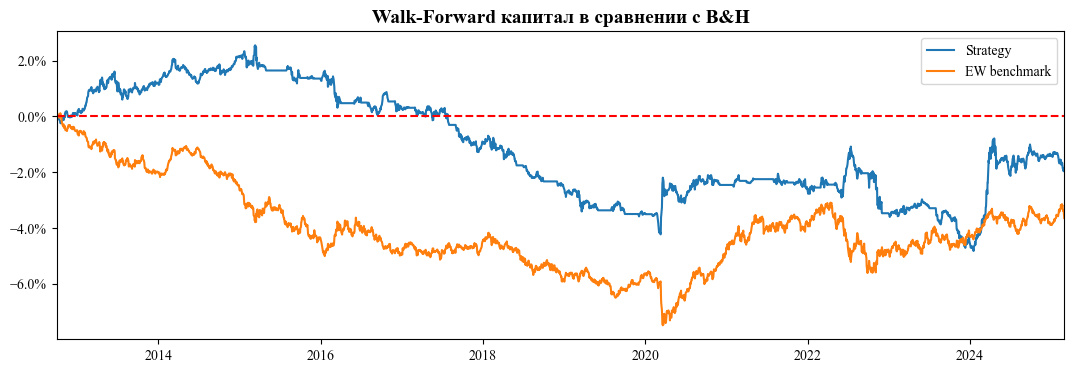

In [99]:
common_idx = eq.index.intersection(bh.index)
eq_plot, bh_plot = eq.loc[common_idx], bh.loc[common_idx]

stats = StatisticsCalc(eq_plot, bh_plot, name="LS WF Strategy")
print(stats)

# Капитализация из лог-ретов
eq_cum = np.exp(eq_plot.cumsum()) - 1.0      # стратегия: кум. доходность (в долях)
bh_cum = np.exp(bh_plot.cumsum()) - 1.0      # бенчмарк: кум. доходность (в долях)

# Капитализация: экспонента от накопленных лог-доходностей
plt.figure(figsize=(13, 4))
plt.plot(eq_cum, label="Strategy")
plt.plot(bh_cum, label="EW benchmark")
plt.title("Walk‑Forward капитал в сравнении с B&H", fontdict={'fontweight':'bold','fontsize':14})
#plt.grid()
plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.axhline(0, color='red', linestyle='--')
ax.margins(x=0)
plt.savefig(r"Рисунки/walk‑forward капитал в сравнении с B&H.png", dpi=300, bbox_inches="tight")
plt.show()

Визуализация весов

Ниже расширенная визуализация весов

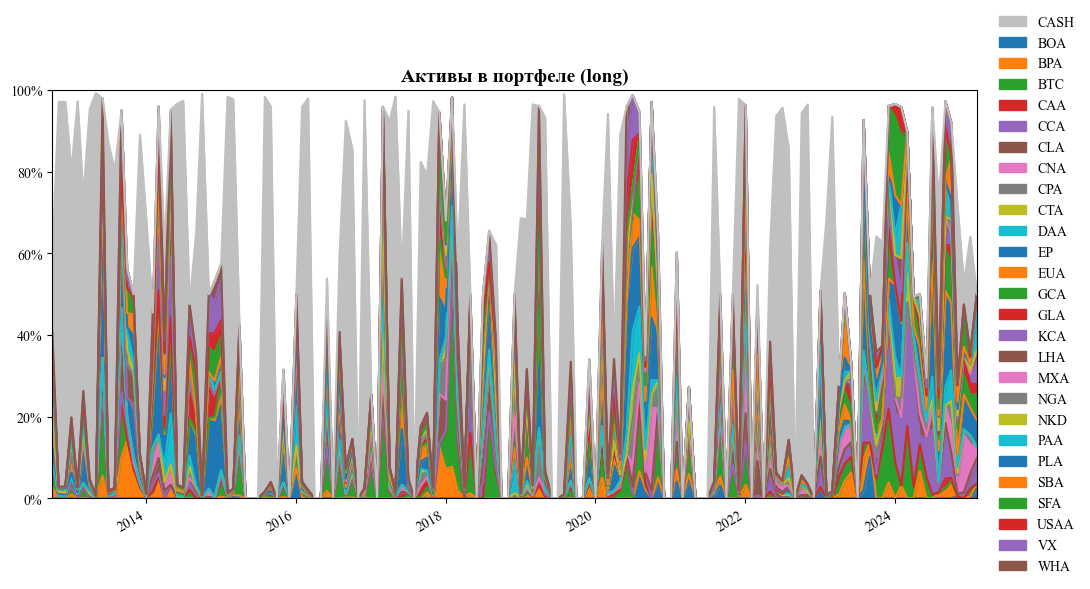

In [100]:
# Длинные (>=0)
fig, ax = plt.subplots(figsize=(11, 6))

cols_all = list(wts.columns)                                    # Порядок столбцов для рисования (чтобы CASH был ВВЕРХУ "стека")
order_stack = [c for c in cols_all if c != 'CASH'] + ['CASH']   # CASH рисуем последним => он сверху
w_plot = wts.clip(lower=0).reindex(columns=order_stack)         # Подготавливаем данные (лонг)

# Цвета: CASH = '#C0C0C0' (серый), остальные — текущая цветовая палитра Matplotlib
from itertools import cycle
auto_colors = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
color_map = {c: next(auto_colors) for c in order_stack}
color_map['CASH'] = '#C0C0C0'
colors_in_order = [color_map[c] for c in order_stack]

# Рисуем
w_plot.plot(kind='area', stacked=True, ax=ax, color=colors_in_order)

ax.set_title('Long exposures (stacked)', fontdict={'fontweight':'bold','fontsize':14})
ax.set_ylim(0, gross_leverage)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.margins(x=0)

# Легенда: переносим CASH на первое место в списке легенды
handles, labels = ax.get_legend_handles_labels()
if 'CASH' in labels:
    i = labels.index('CASH')
    handles = [handles[i]] + handles[:i] + handles[i+1:]
    labels  = [labels[i]]  + labels[:i]  + labels[i+1:]
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1)

plt.title('Активы в портфеле (long)', fontdict={'fontweight':'bold','fontsize':14})
plt.savefig(r"Рисунки/aктивы в портфеле (long).png", dpi=300, bbox_inches="tight")
plt.tight_layout()

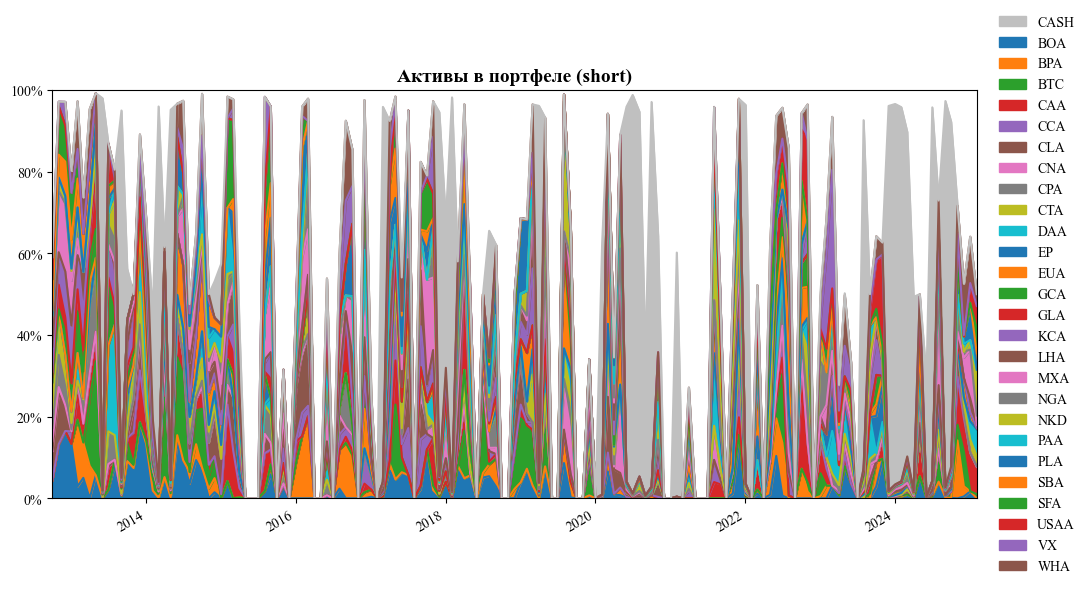

In [101]:
# Короткие (<=0)
fig, ax = plt.subplots(figsize=(11, 6))

cols_all = list(wts.columns)                                    # Порядок столбцов для рисования (чтобы CASH был ВВЕРХУ "стека")
order_stack = [c for c in cols_all if c != 'CASH'] + ['CASH']   # CASH рисуем последним => он сверху
w_plot = wts.clip(upper=0).abs().reindex(columns=order_stack)         # Подготавливаем данные (лонг)

# Цвета: CASH = '#C0C0C0' (серый), остальные — текущая цветовая палитра Matplotlib
from itertools import cycle
auto_colors = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
color_map = {c: next(auto_colors) for c in order_stack}
color_map['CASH'] = '#C0C0C0'
colors_in_order = [color_map[c] for c in order_stack]

# Рисуем
w_plot.plot(kind='area', stacked=True, ax=ax, color=colors_in_order)

ax.set_title('Long exposures (stacked)', fontdict={'fontweight':'bold','fontsize':14})
ax.set_ylim(0, gross_leverage)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.margins(x=0)

# Легенда: переносим CASH на первое место в списке легенды
handles, labels = ax.get_legend_handles_labels()
if 'CASH' in labels:
    i = labels.index('CASH')
    handles = [handles[i]] + handles[:i] + handles[i+1:]
    labels  = [labels[i]]  + labels[:i]  + labels[i+1:]
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1)

plt.title('Активы в портфеле (short)', fontdict={'fontweight':'bold','fontsize':14})
plt.savefig(r"Рисунки/aктивы в портфеле (short).png", dpi=300, bbox_inches="tight")
plt.tight_layout()

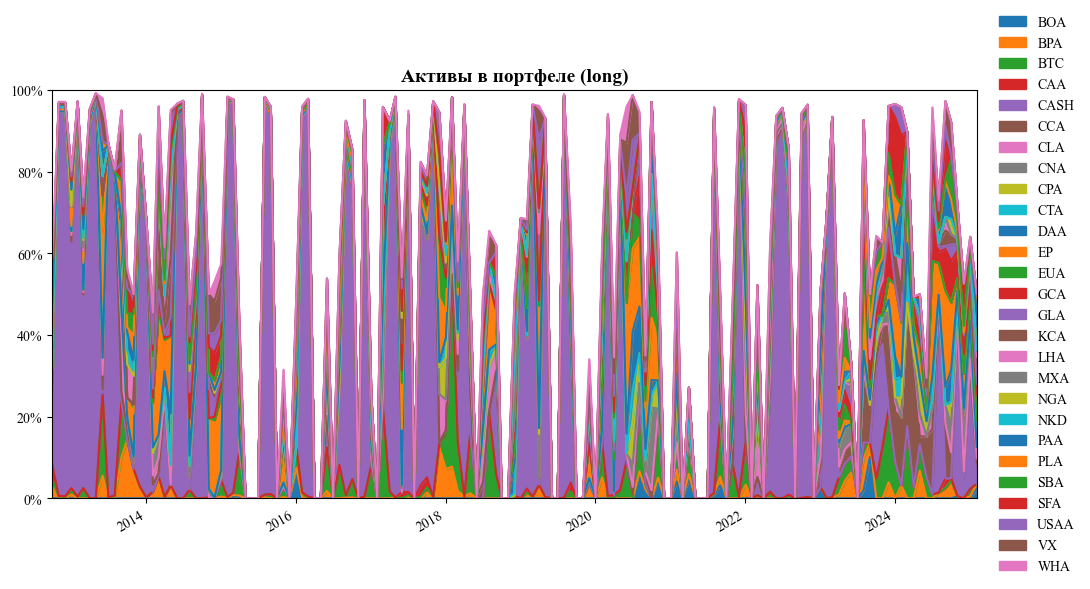

In [102]:
# === 7) РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ ВЕСОВ ===
# Длинные (>=0)
fig, ax = plt.subplots(figsize=(11, 6))
wts.clip(lower=0).plot(kind='area', stacked=True, ax=ax)
ax.set_title('Long exposures (stacked)', fontdict={'fontweight':'bold','fontsize':14})
                                           # else auto-scale

ax.set_ylim(0, gross_leverage) # Верхняя граница
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) # percentages on the axis Y
ax.margins(x=0)  # removing the empty fields by X
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1) # легенду за пределы графика

plt.title('Активы в портфеле (long)', fontdict={'fontweight': 'bold', 'fontsize': 14})
#plt.savefig(r"Рисунки/aктивы в портфеле (long).png", dpi=300, bbox_inches="tight")
plt.tight_layout()

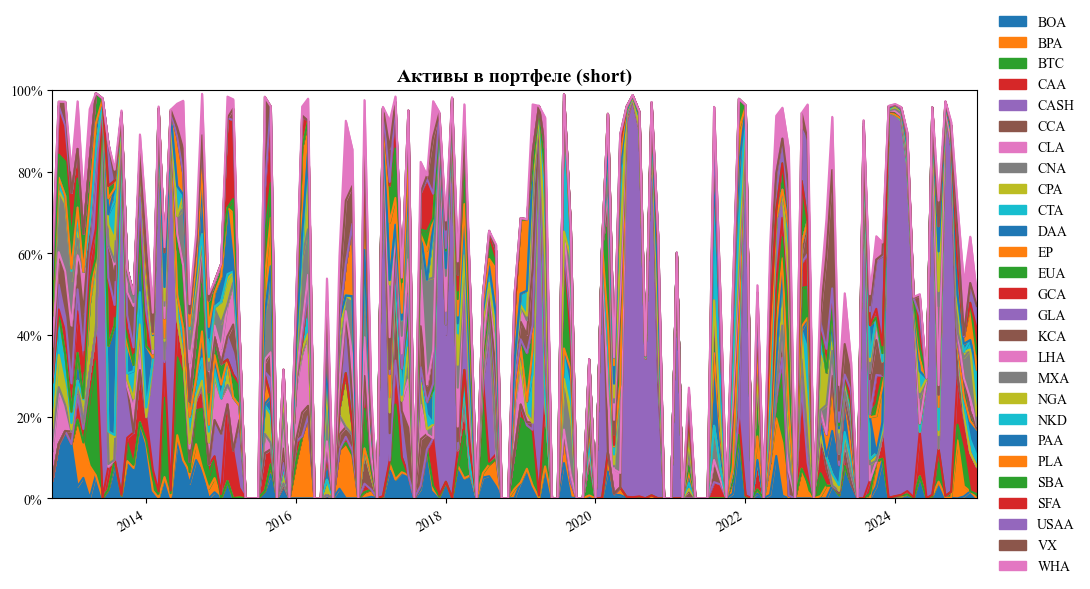

In [103]:
# Короткие (<=0) по модулю
fig, ax = plt.subplots(figsize=(11, 6))
wts.clip(upper=0).abs().plot(kind='area', stacked=True, ax=ax)
ax.set_title('Short exposures (stacked, absolute)', fontdict={'fontweight':'bold','fontsize':14})

ax.set_ylim(0, gross_leverage) # Верхняя граница                                            # else auto-scale
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) # percentages on the axis Y
ax.margins(x=0)  # removing the empty fields by X
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1) # легенду за пределы графика

plt.title('Активы в портфеле (short)', fontdict={'fontweight': 'bold', 'fontsize': 14})
#plt.savefig(r"Рисунки/aктивы в портфеле (short).png", dpi=300, bbox_inches="tight")
plt.tight_layout()

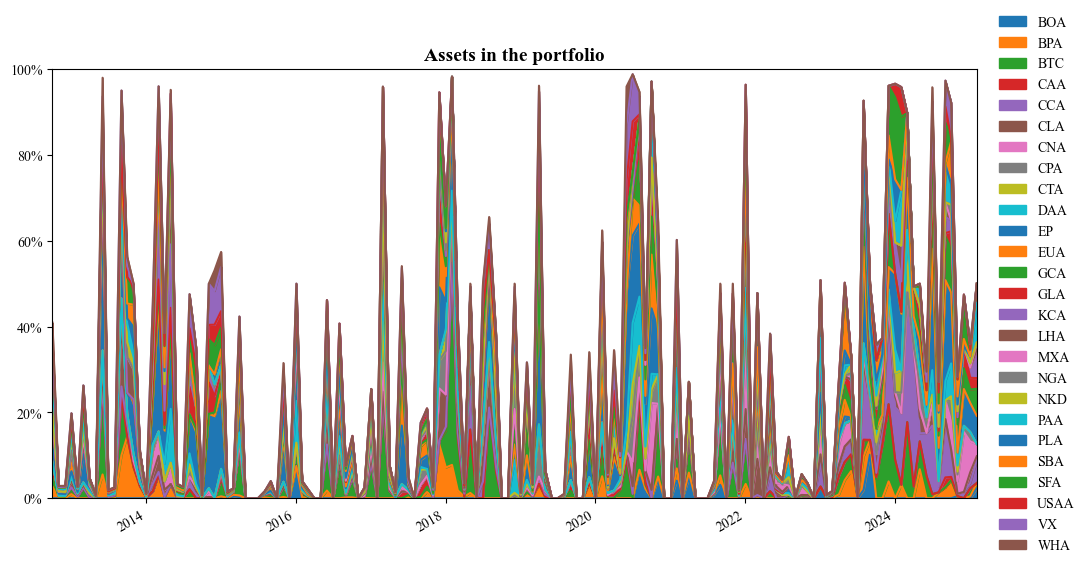

In [104]:
# === 7) РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ ВЕСОВ ===
# Длинные (>=0)
fig, ax = plt.subplots(figsize=(11, 6))
wts.drop(columns='CASH').clip(lower=0).plot(kind='area', stacked=True, ax=ax)
ax.set_title('Long exposures (stacked)', fontdict={'fontweight':'bold','fontsize':14})
                                           # else auto-scale

ax.set_ylim(0, gross_leverage) # Верхняя граница
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) # percentages on the axis Y
ax.margins(x=0)  # removing the empty fields by X
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1) # легенду за пределы графика

plt.title('Assets in the portfolio', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.tight_layout()

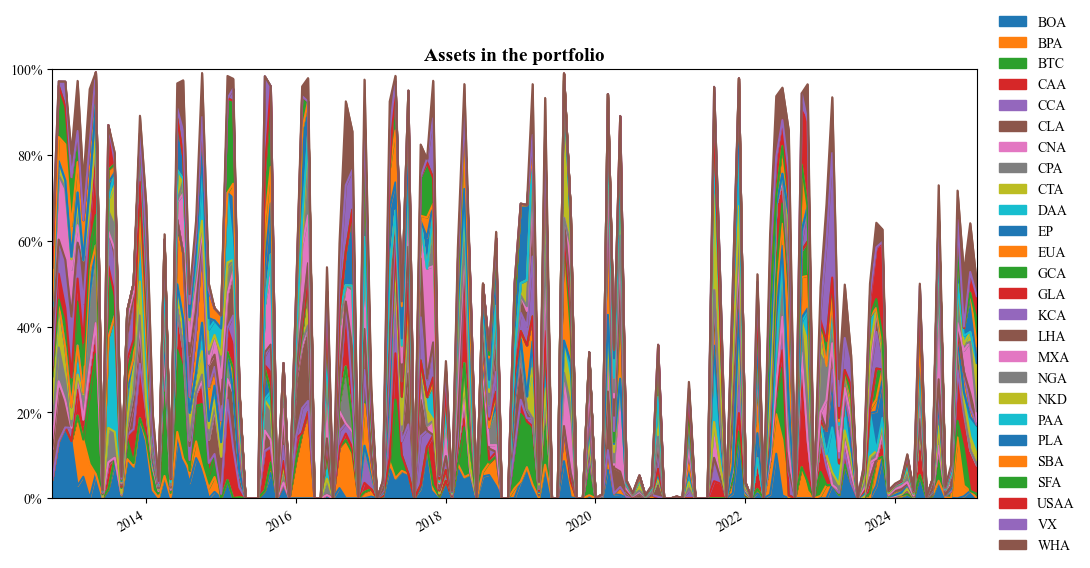

In [105]:
# Короткие (<=0) по модулю
fig, ax = plt.subplots(figsize=(11, 6))
wts.drop(columns='CASH').clip(upper=0).abs().plot(kind='area', stacked=True, ax=ax)
ax.set_title('Short exposures (stacked, absolute)', fontdict={'fontweight':'bold','fontsize':14})

ax.set_ylim(0, gross_leverage) # Верхняя граница                                            # else auto-scale
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) # percentages on the axis Y
ax.margins(x=0)  # removing the empty fields by X
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1) # легенду за пределы графика

plt.title('Assets in the portfolio', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.tight_layout()

In [106]:
#Проверка, есть ли кэш-периоды
is_zero_fold = (wts.drop(columns='CASH').abs().sum(axis=1) <= 1e-12) 
print("Отключенных подпериодов:", int(is_zero_fold.sum()), "из", len(wts))

Отключенных подпериодов: 31 из 149


In [107]:
wts.tail(10)

,BOA,BPA,BTC,CAA,CASH,CCA,CLA,CNA,CPA,CTA,...,MXA,NGA,NKD,PAA,PLA,SBA,SFA,USAA,VX,WHA
2024-05-01,-0.053961,0.067594,0.065013,-0.109056,5.551115e-17,0.018728,0.037809,0.020113,0.064342,0.019805,...,-0.062424,-0.014111,-0.051157,0.043772,-0.030096,-0.027378,-0.078720,0.007415,-0.047202,-0.005223
2024-06-03,-0.000539,-0.000010,0.052122,-0.000244,-2.912461e-01,0.100000,-0.000073,-0.000134,0.031647,0.005010,...,-0.000414,-0.000038,-0.000401,-0.000508,-0.000045,-0.000434,-0.000269,-0.000051,-0.000241,0.022748
2024-07-01,-0.005925,0.000035,0.009550,-0.002968,-9.148442e-01,0.159870,0.051375,-0.004092,0.020393,-0.001839,...,-0.017573,0.001577,-0.002831,0.014175,-0.001961,0.001986,-0.000879,0.056322,0.032801,0.033026
2024-08-01,-0.040852,0.013850,-0.077641,-0.003685,4.583861e-01,0.013126,0.012880,-0.000110,-0.032494,-0.012635,...,-0.192918,-0.037285,-0.097437,0.032841,-0.061680,0.004133,0.016823,0.025551,0.024568,-0.062610
2024-09-03,-0.001863,0.025745,-0.004209,0.022917,-9.458574e-01,0.135655,-0.000015,0.044008,-0.000827,-0.000205,...,-0.009577,-0.000602,-0.002302,0.087219,-0.003624,0.004136,0.094431,0.037311,0.060467,-0.002239
2024-10-01,-0.001053,0.042463,-0.015319,0.007363,-8.436804e-01,0.062758,-0.006292,0.066657,0.046890,0.011511,...,-0.023122,0.037038,-0.007361,0.047457,-0.010074,0.100121,0.007996,-0.000937,0.082332,-0.008855
2024-11-01,0.004872,-0.141845,-0.038543,-0.117379,4.334615e-01,0.005793,-0.078496,0.029123,0.015594,0.006849,...,0.001005,-0.057069,-0.033289,0.016195,-0.076844,0.018326,0.039861,-0.072946,0.006377,-0.068290
2024-12-02,-0.004630,-0.024792,-0.084952,-0.082356,5.089056e-02,0.014578,-0.010868,0.139929,0.014338,-0.023245,...,-0.049165,-0.014877,0.000582,-0.019522,-0.018109,0.016142,0.076330,0.026983,-0.003274,-0.125524
2025-01-02,-0.017078,0.004679,0.018557,-0.094755,2.814015e-01,0.012312,0.024919,0.071861,0.022091,-0.032422,...,-0.120187,0.009690,-0.023241,0.015802,-0.081815,-0.009352,0.016672,-0.048479,0.012726,-0.113356
2025-02-03,0.022951,0.012495,-0.010397,-0.066654,1.387779e-17,0.052391,0.010144,0.028162,-0.001297,-0.025154,...,0.016089,-0.024132,-0.112352,0.092438,0.044714,-0.039556,-0.059482,-0.050062,-0.006703,-0.029018


In [108]:
row = wts.loc[pd.Timestamp('2024-11-01')]                  # все веса по активам + CASH в этот момент
row                        # Series

BOA     0.004872
BPA    -0.141845
BTC    -0.038543
CAA    -0.117379
CASH    0.433462
CCA     0.005793
CLA    -0.078496
CNA     0.029123
CPA     0.015594
CTA     0.006849
DAA     0.014292
EP      0.030006
EUA    -0.011757
GCA     0.065728
GLA     0.016685
KCA    -0.020273
LHA     0.012564
MXA     0.001005
NGA    -0.057069
NKD    -0.033289
PAA     0.016195
PLA    -0.076844
SBA     0.018326
SFA     0.039861
USAA   -0.072946
VX      0.006377
WHA    -0.068290
Name: 2024-11-01 00:00:00, dtype: float64

In [109]:
risk_row = row.drop(labels='CASH')

sum_positive = risk_row.clip(lower=0).sum()      # сумма лонгов
sum_negative = risk_row.clip(upper=0).sum()      # сумма шортов (отрицательное число)
sum_shorts_abs = risk_row.clip(upper=0).abs().sum()  # сумма шортов по модулю

net_sum = risk_row.sum()          # нетто по риск-части
cash_value = float(row['CASH'])   # кэш = 1 - net_sum

In [110]:
sum_positive

np.float64(0.2832692474965309)

In [111]:
sum_negative

np.float64(-0.7167307525034692)

In [112]:
cash_value

0.4334615050069382

In [113]:
sum_positive + sum_negative + cash_value

np.float64(-1.1102230246251565e-16)

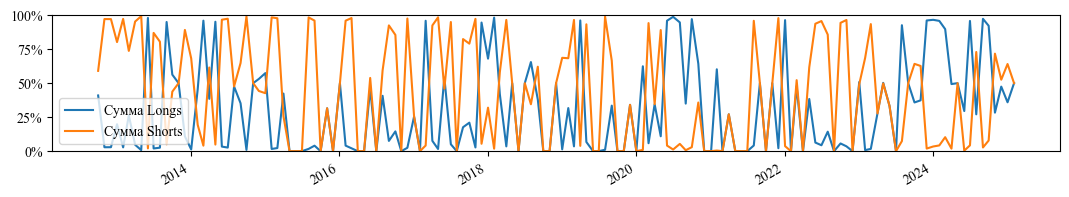

In [119]:
# сумма лонгов и шортов
sum_longs  = wts.drop(columns='CASH').clip(lower=0).sum(axis=1)
sum_shorts = wts.drop(columns='CASH').clip(upper=0).abs().sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 2))
sum_longs.plot(ax=ax, label='Сумма Longs')
sum_shorts.plot(ax=ax, label='Сумма Shorts')
ax.set_ylim(0, gross_leverage)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend()
plt.savefig(r"Рисунки/Сумма long-short.png", dpi=300, bbox_inches="tight")
plt.show()